# Análisis exploratorio de datos

Este capítulo contiene el EDA completo en Python. Las secciones 1 a 1.10 responden al objetivo específico 1 (conocer los datos), la sección 1.11 al objetivo específico 2 (la variable objetivo del modelo) y las {ref}`conclusiones <conclusiones>` al objetivo específico 3 (implicaciones para el modelo). Ver los {ref}`objetivos <objetivos>`. Cada resultado va seguido de su **interpretación**.

```{admonition} Cómo leer este capítulo
:class: note
Las cajas verdes **Interpretación** explican qué muestra cada tabla o gráfico. Las cajas naranjas **Precaución** señalan problemas de calidad de datos que cambian la lectura de un resultado.
```

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 6), "figure.dpi": 110, "axes.titlesize": 15, "axes.titleweight": "bold", "font.size": 11, "axes.edgecolor": "#BBBBBB"})
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)

df = pd.read_csv("dataset_calidad_aire.csv")
print("CSV cargado, iniciando limpieza...")

CSV cargado, iniciando limpieza...


In [2]:
# Limpio columnas que vienen como strings pero son números
df["Año"] = df["Año"].astype(str).str.replace(",", "").astype(int)
columnas_numericas = ["ID Estacion", "Suma", "No. de datos", "Promedio", "Mediana", "Percentil 98", "Máximo", "Mínimo"]
for col in columnas_numericas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(",", "").str.strip()
        df[col] = pd.to_numeric(df[col], errors="coerce")
print("Limpieza completada")
print(df.dtypes)

Limpieza completada
ID Estacion                               int64
Autoridad Ambiental                         str
Estación                                    str
Latitud                                 float64
Longitud                                float64
Variable                                    str
Unidades                                    str
Tiempo de exposición (horas)              int64
Año                                       int64
Promedio                                float64
Suma                                    float64
No. de datos                              int64
Representatividad Temporal              float64
Excedencias limite actual                 int64
Porcentaje excedencias limite actual    float64
Mediana                                 float64
Percentil 98                            float64
Máximo                                  float64
Fechas/horas del máximo                     str
Mínimo                                  float64
Fechas/horas del mín

```{admonition} Interpretación
:class: tip
Las columnas numéricas venían como texto con comas de miles (por ejemplo `"1,003.6"`). Al quitar las comas y convertirlas, todas quedan como `float64` o `int64` y se pueden usar en cálculos. Sin este paso, cualquier promedio o gráfico habría fallado o devuelto valores nulos.
```

In [3]:
# Helper para mostrar tablas parecidas a las de knitr::kable + kableExtra
def tabla(d, columnas=None, decimales=2):
    d = d.copy()
    if columnas is not None: d.columns = columnas
    return d.round(decimales).style.hide(axis="index").set_table_styles([{"selector": "th, td", "props": [("border", "1px solid #999999"), ("padding", "4px 10px"), ("text-align", "left")]}])

## 1. Preparación y calidad de los datos

*Objetivo específico 1 · calidad de los datos.*

In [4]:
df.shape

(29683, 28)

```{admonition} Interpretación
:class: tip
El archivo original tiene 29.683 filas y 28 columnas. Cada fila es el **resumen anual** de una variable, en una estación y para un tiempo de exposición, no una medición individual.
```

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29683 entries, 0 to 29682
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID Estacion                           29683 non-null  int64  
 1   Autoridad Ambiental                   29683 non-null  str    
 2   Estación                              29683 non-null  str    
 3   Latitud                               29683 non-null  float64
 4   Longitud                              29683 non-null  float64
 5   Variable                              29683 non-null  str    
 6   Unidades                              29683 non-null  str    
 7   Tiempo de exposición (horas)          29683 non-null  int64  
 8   Año                                   29683 non-null  int64  
 9   Promedio                              29683 non-null  float64
 10  Suma                                  29683 non-null  float64
 11  No. de datos              

In [6]:
list(df.columns)

['ID Estacion',
 'Autoridad Ambiental',
 'Estación',
 'Latitud',
 'Longitud',
 'Variable',
 'Unidades',
 'Tiempo de exposición (horas)',
 'Año',
 'Promedio',
 'Suma',
 'No. de datos',
 'Representatividad Temporal',
 'Excedencias limite actual',
 'Porcentaje excedencias limite actual',
 'Mediana',
 'Percentil 98',
 'Máximo',
 'Fechas/horas del máximo',
 'Mínimo',
 'Fechas/horas del mínimo',
 'Días de excedencias',
 'Código del Departamento',
 'Nombre del Departamento',
 'Código del Municipio',
 'Nombre del Municipio',
 'Tipo de Estación',
 'Ubicacion']

In [7]:
df.isna().sum()

ID Estacion                               0
Autoridad Ambiental                       0
Estación                                  0
Latitud                                   0
Longitud                                  0
Variable                                  0
Unidades                                  0
Tiempo de exposición (horas)              0
Año                                       0
Promedio                                  0
Suma                                      0
No. de datos                              0
Representatividad Temporal              148
Excedencias limite actual                 0
Porcentaje excedencias limite actual      0
Mediana                                   0
Percentil 98                              0
Máximo                                    0
Fechas/horas del máximo                   0
Mínimo                                    0
Fechas/horas del mínimo                   0
Días de excedencias                       0
Código del Departamento         

In [8]:
porcentaje_na = df.isna().sum() / len(df) * 100
porcentaje_na

ID Estacion                             0.000000
Autoridad Ambiental                     0.000000
Estación                                0.000000
Latitud                                 0.000000
Longitud                                0.000000
Variable                                0.000000
Unidades                                0.000000
Tiempo de exposición (horas)            0.000000
Año                                     0.000000
Promedio                                0.000000
Suma                                    0.000000
No. de datos                            0.000000
Representatividad Temporal              0.498602
Excedencias limite actual               0.000000
Porcentaje excedencias limite actual    0.000000
Mediana                                 0.000000
Percentil 98                            0.000000
Máximo                                  0.000000
Fechas/horas del máximo                 0.000000
Mínimo                                  0.000000
Fechas/horas del mín

```{admonition} Interpretación
:class: tip
Solo tres columnas tienen faltantes y ninguna supera el 0,5 %: `Representatividad Temporal` (148 filas), `Código del Municipio` (4) y `Tipo de Estación` (2). Las columnas que usa el análisis (`Variable`, `Año`, `Promedio`) están completas, así que no hace falta imputar ni eliminar filas por faltantes.
```

In [9]:
df.duplicated().sum()

np.int64(13938)

In [10]:
df_unicos = df.drop_duplicates()
print("Filas originales:", len(df))
print("Filas únicas:", len(df_unicos))
print("Duplicados:", len(df) - len(df_unicos))

Filas originales: 29683
Filas únicas: 15745
Duplicados: 13938


In [11]:
porcentaje_duplicados = df.duplicated().sum() / len(df) * 100
print("Porcentaje de filas duplicadas:", round(porcentaje_duplicados, 2), "%")

Porcentaje de filas duplicadas: 46.96 %


```{admonition} Interpretación
:class: tip
Casi la mitad del archivo (46,96 %) son filas idénticas a otra. Una proporción así indica que el consolidado se armó juntando reportes que se solaparon, no que se repitieran mediciones reales. Si no se eliminaran, cada estación duplicada pesaría el doble en promedios y conteos. Por eso el resto del análisis trabaja con las **15.745 filas únicas**.
```

In [12]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(15745, 28)

In [13]:
df.duplicated().sum()

np.int64(0)

### 1.1 Exploración general del dataset

*Objetivo específico 1 · cobertura del monitoreo.*

In [14]:
df["Variable"].value_counts().sort_index()

Variable
CO           719
DViento     1099
HAire         75
HAire10      361
HAire2       693
NO           291
NO2          644
O3           827
P            673
PLiquida     927
PM10        2984
PM2.5       1984
PST          241
RGlobal      600
RUVb          66
SO2         1066
TAire         73
TAire10      334
TAire2       834
VViento     1254
Name: count, dtype: int64

In [15]:
df["Variable"].nunique()

20

```{admonition} Interpretación
:class: tip
Hay 20 variables, que se agrupan en contaminantes (PM10, PM2.5, PST, NO, NO₂, O₃, SO₂, CO) y meteorológicas (temperatura, humedad, viento, presión, precipitación y radiación). La temperatura y la humedad aparecen en tres versiones (sin altura, a 2 m y a 10 m), que son variables distintas y no deben mezclarse.
```

#### 1.1.1 Distribución de registros por estación

In [16]:
df["Estación"].nunique()

654

In [17]:
registros_estacion = df["Estación"].value_counts().rename_axis("Estación").reset_index(name="n")
registros_estacion.head(10)

,Estación,n
0,C. ALTO RENDIMIENTO,281
1,KENNEDY,281
2,TUNAL,265
3,LAS FERIAS,256
4,GUAYMARAL,250
5,PUENTE ARANDA,247
6,CARVAJAL - SEVILLANA,245
7,SAN CRISTÓBAL,224
8,SUBA,214
9,POLITÉCNICO JIC,212


In [18]:
def barras_h(d, cat, val, titulo, xlab, ylab, subtitulo=None, alto=6, tam=9, dec=0):
    d = d.sort_values(val)
    fig, ax = plt.subplots(figsize=(9, alto))
    ax.barh(d[cat].astype(str), d[val], color="#595959")
    for y, v in zip(d[cat].astype(str), d[val]): ax.text(v * 1.01, y, f"{v:.{dec}f}", va="center", fontsize=tam)
    ax.set_xlim(0, d[val].max() * 1.08)
    ax.set_title(titulo if subtitulo is None else titulo + "\n" + subtitulo, fontweight="bold")
    ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()

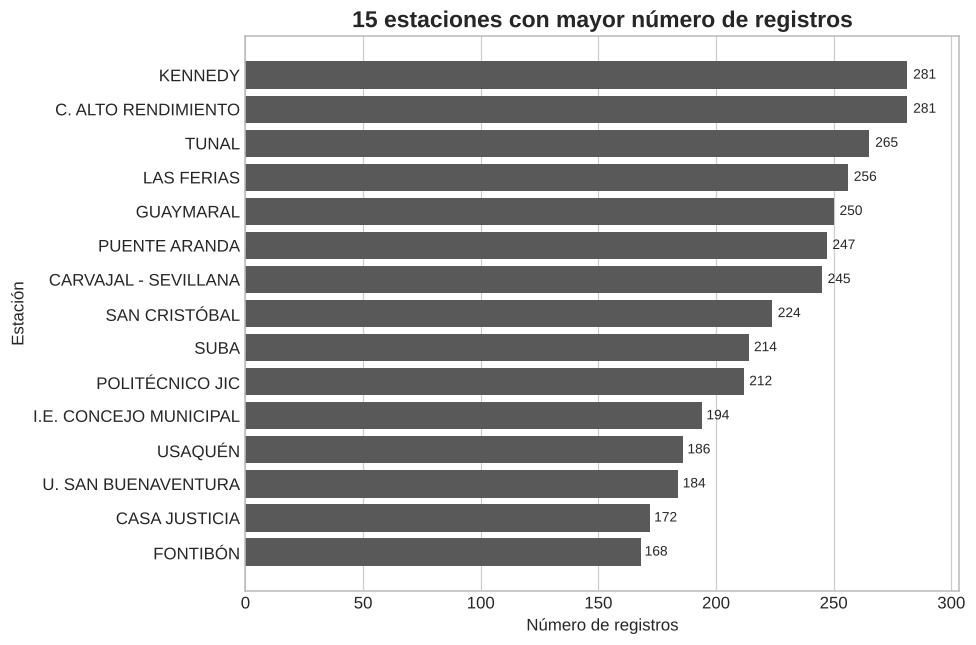

In [19]:
top_estaciones = registros_estacion.nlargest(15, "n")
barras_h(top_estaciones, "Estación", "n", "15 estaciones con mayor número de registros", "Número de registros", "Estación")

```{admonition} Interpretación
:class: tip
Las estaciones con más registros (Centro de Alto Rendimiento, Kennedy, Tunal, Las Ferias, Guaymaral, Puente Aranda) son todas de **Bogotá**. Son estaciones que miden muchas variables a la vez durante todo el periodo, por eso dominan el conteo.
```

#### 1.1.2 Distribución de registros por variable ambiental

In [20]:
frecuencia_variables = df["Variable"].value_counts().rename_axis("Variable").reset_index(name="n")
frecuencia_variables

,Variable,n
0,PM10,2984
1,PM2.5,1984
2,VViento,1254
3,DViento,1099
4,SO2,1066
5,PLiquida,927
6,TAire2,834
7,O3,827
8,CO,719
9,HAire2,693


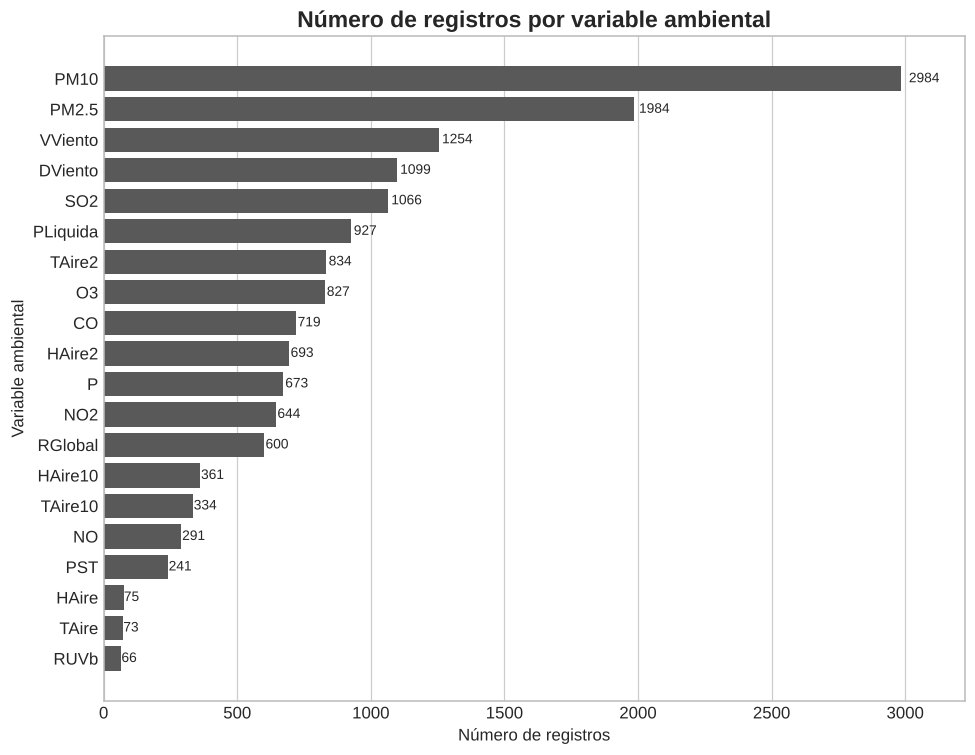

In [21]:
barras_h(frecuencia_variables, "Variable", "n", "Número de registros por variable ambiental", "Número de registros", "Variable ambiental", alto=7)

```{admonition} Interpretación
:class: tip
PM10 y PM2.5 suman casi un tercio de los registros: el material particulado es el contaminante más vigilado por su efecto en la salud. En el otro extremo, TAire, HAire y RUVb tienen menos de 80 registros cada uno, así que cualquier conclusión sobre ellos descansa en muy poca información.
```

### 1.2 Distribución temporal de los registros

In [22]:
frecuencia_anios = df["Año"].value_counts().rename_axis("Año").reset_index(name="n").sort_values("Año")
frecuencia_anios

,Año,n
13,2011,647
12,2012,809
8,2013,912
10,2014,864
9,2015,903
5,2016,966
3,2017,1354
4,2018,1155
7,2019,932
2,2020,1598


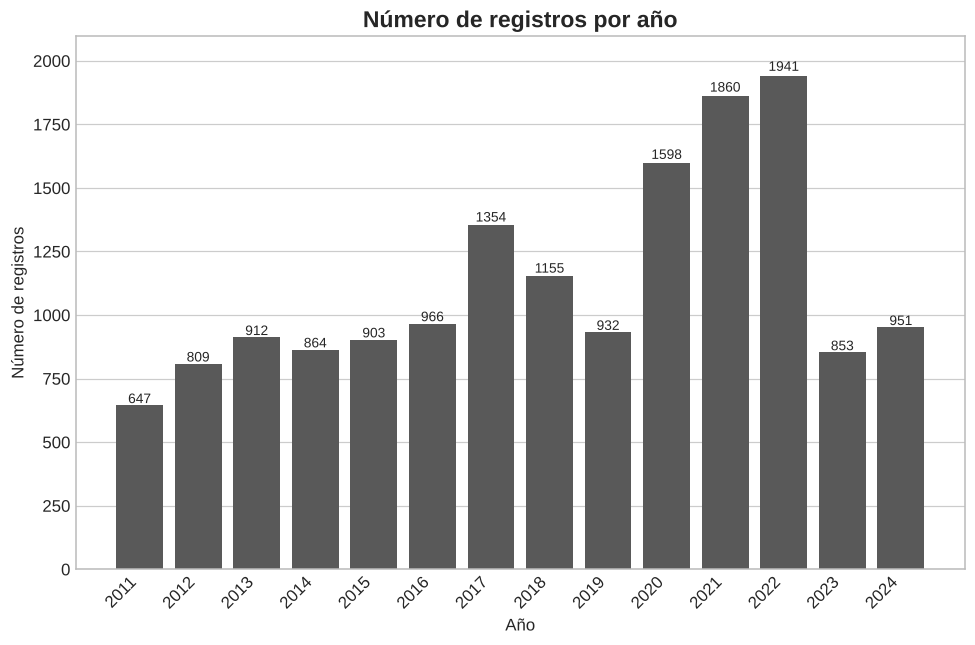

In [23]:
fig, ax = plt.subplots()
ax.bar(frecuencia_anios["Año"].astype(str), frecuencia_anios["n"], color="#595959")
for x, v in zip(frecuencia_anios["Año"].astype(str), frecuencia_anios["n"]): ax.text(x, v * 1.01, str(v), ha="center", fontsize=9)
ax.set_ylim(0, frecuencia_anios["n"].max() * 1.08)
ax.set_title("Número de registros por año", fontweight="bold"); ax.set_xlabel("Año"); ax.set_ylabel("Número de registros")
plt.xticks(rotation=45, ha="right"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
Los registros pasan de 647 en 2011 a 1.941 en 2022: la red de monitoreo se triplicó. La caída de 2023–2024 puede deberse a reportes incompletos o al cierre de estaciones; el dataset no permite distinguirlo.

**Consecuencia para el análisis:** cuando el promedio anual de una variable cambia, parte del cambio puede venir de que entraron o salieron estaciones, y no solo de cambios reales en el aire.
```

### 1.3 Estadística descriptiva y distribución de variables ambientales

In [24]:
estadistica_variables = df.groupby("Variable", as_index=False).agg(n=("Promedio", "size"), Media=("Promedio", "mean"), Mediana=("Promedio", "median"), Desviacion_Estandar=("Promedio", "std"), Minimo=("Promedio", "min"), Q1=("Promedio", lambda s: s.quantile(0.25)), Q3=("Promedio", lambda s: s.quantile(0.75)), Maximo=("Promedio", "max"))
estadistica_variables

,Variable,n,Media,Mediana,Desviacion_Estandar,Minimo,Q1,Q3,Maximo
0,CO,719,811.864668,692.964695,487.497846,0.8,484.600,957.203556,3294.800000
1,DViento,1099,167.279527,168.800000,99.266649,0.4,83.650,248.300000,359.400000
2,HAire,75,66.092000,71.800000,15.987485,33.1,62.050,76.350000,92.000000
3,HAire10,361,68.364820,69.100000,11.248304,28.0,65.000,75.800000,87.400000
4,HAire2,693,70.517605,71.300000,11.260156,18.1,66.600,78.000000,90.500000
5,NO,291,25.003174,20.800000,18.907793,0.2,11.750,34.250000,97.200000
6,NO2,644,26.459789,26.000000,12.492855,0.5,16.500,35.600000,65.600000
7,O3,827,26.151963,25.700000,9.170727,2.0,19.800,31.800000,65.800000
8,P,673,701.680684,677.600000,116.808434,399.1,629.900,755.500000,1010.400000
9,PLiquida,927,9.771090,1.400000,122.038956,0.1,0.200,3.400000,3236.700000


```{admonition} Interpretación
:class: tip
Las escalas son muy distintas (presión cerca de 700 mmHg, viento cerca de 1 m/s), así que cada variable solo se compara consigo misma.

En casi todos los contaminantes la media es mayor que la mediana (PM10: 37,1 frente a 34,6; SO₂: 9,4 frente a 6,0). Eso indica **asimetría positiva**: unas pocas estaciones con valores altos jalan el promedio hacia arriba.

**PLiquida** es el caso extremo: su media (9,8 mm) es siete veces la mediana (1,4 mm) por unos pocos valores enormes (máximo 3.236,7 mm). Para esta variable la mediana es la medida de tendencia central adecuada.
```

#### Distribución de las variables ambientales

In [25]:
vars_orden = sorted(df["Variable"].unique())
def panel_boxplots(inicio, fin, subtitulo):
    grupo = vars_orden[inicio:fin]
    filas = int(np.ceil(len(grupo) / 2))
    fig, axes = plt.subplots(filas, 2, figsize=(9, 3.2 * filas))
    axes = np.array(axes).ravel()
    for ax, v in zip(axes, grupo):
        ax.boxplot(df.loc[df["Variable"] == v, "Promedio"].dropna(), widths=0.5)
        ax.set_title(v, fontweight="bold", fontsize=12); ax.set_xticks([]); ax.set_ylabel("Valor promedio"); ax.grid(axis="x", visible=False)
    for ax in axes[len(grupo):]: ax.axis("off")
    fig.suptitle("Distribución de las variables ambientales\n" + subtitulo, fontweight="bold", fontsize=15)
    plt.tight_layout(); plt.show()

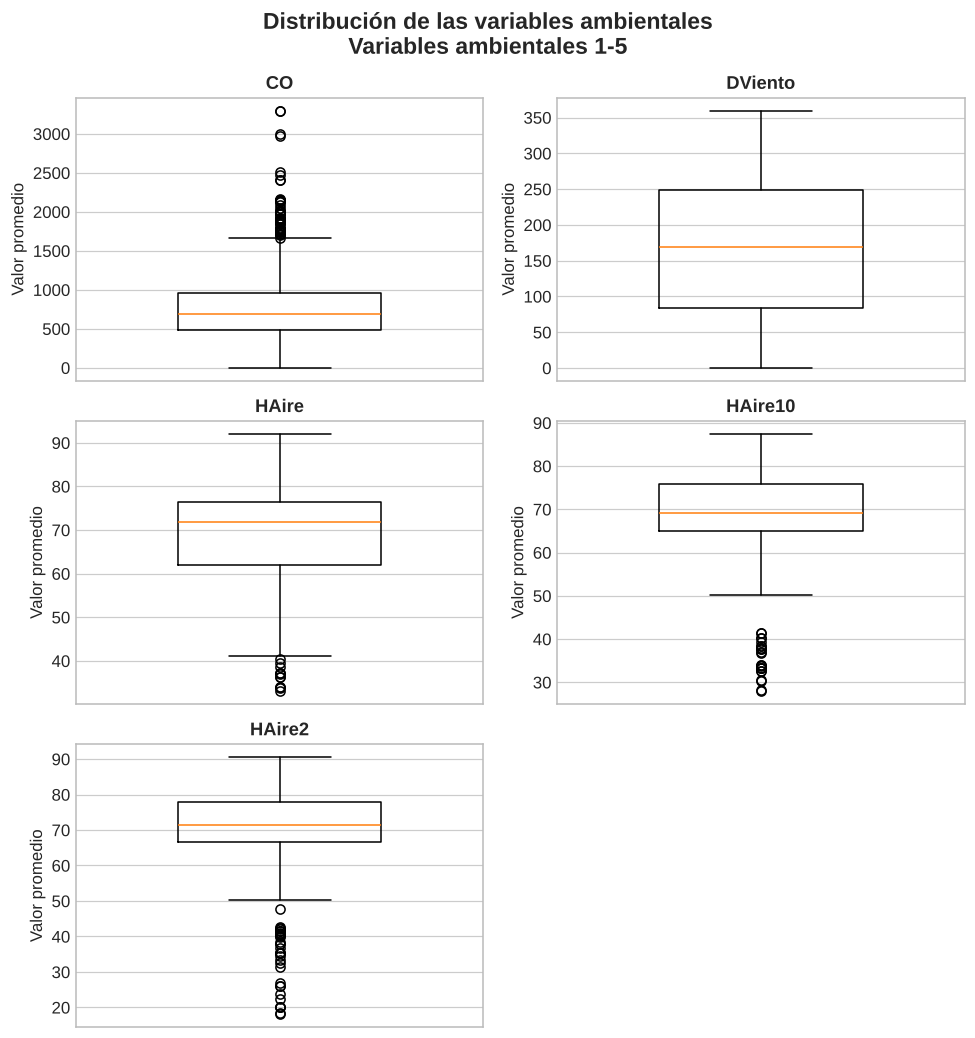

In [26]:
panel_boxplots(0, 5, "Variables ambientales 1-5")

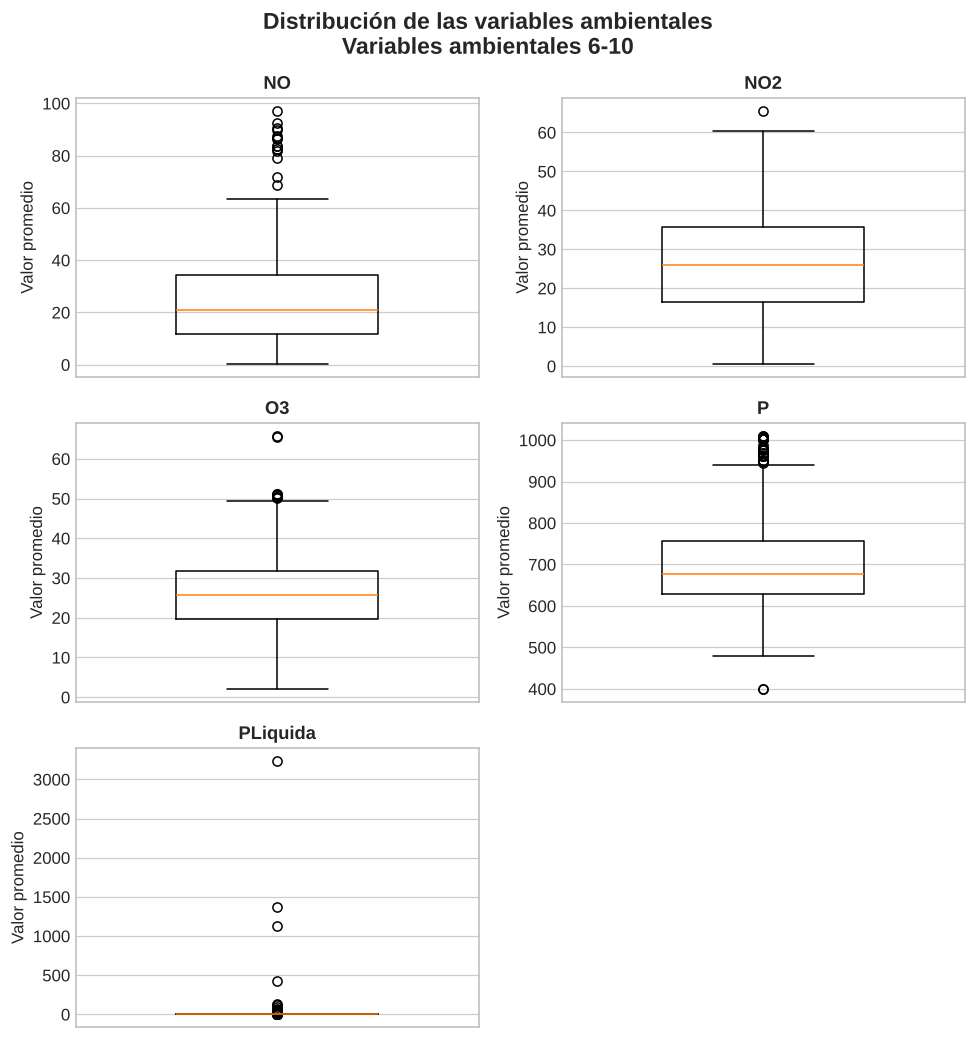

In [27]:
panel_boxplots(5, 10, "Variables ambientales 6-10")

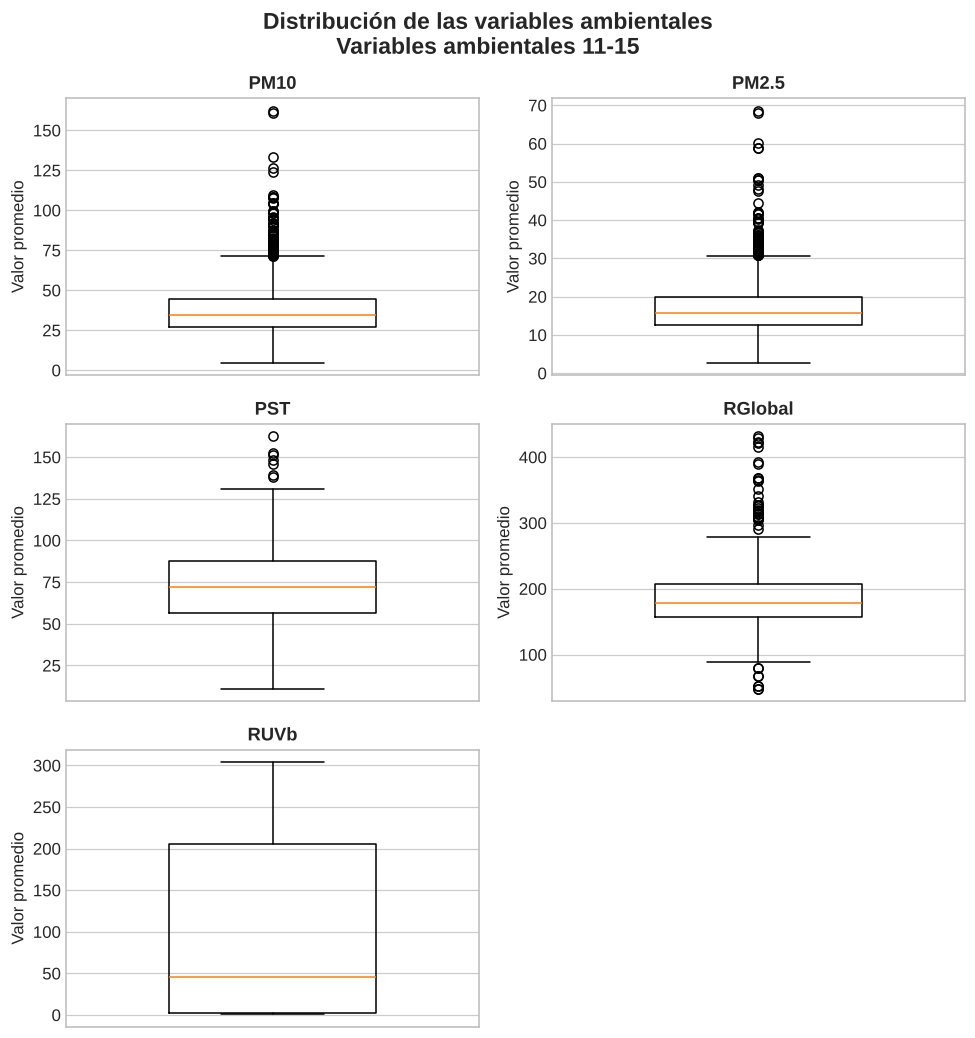

In [28]:
panel_boxplots(10, 15, "Variables ambientales 11-15")

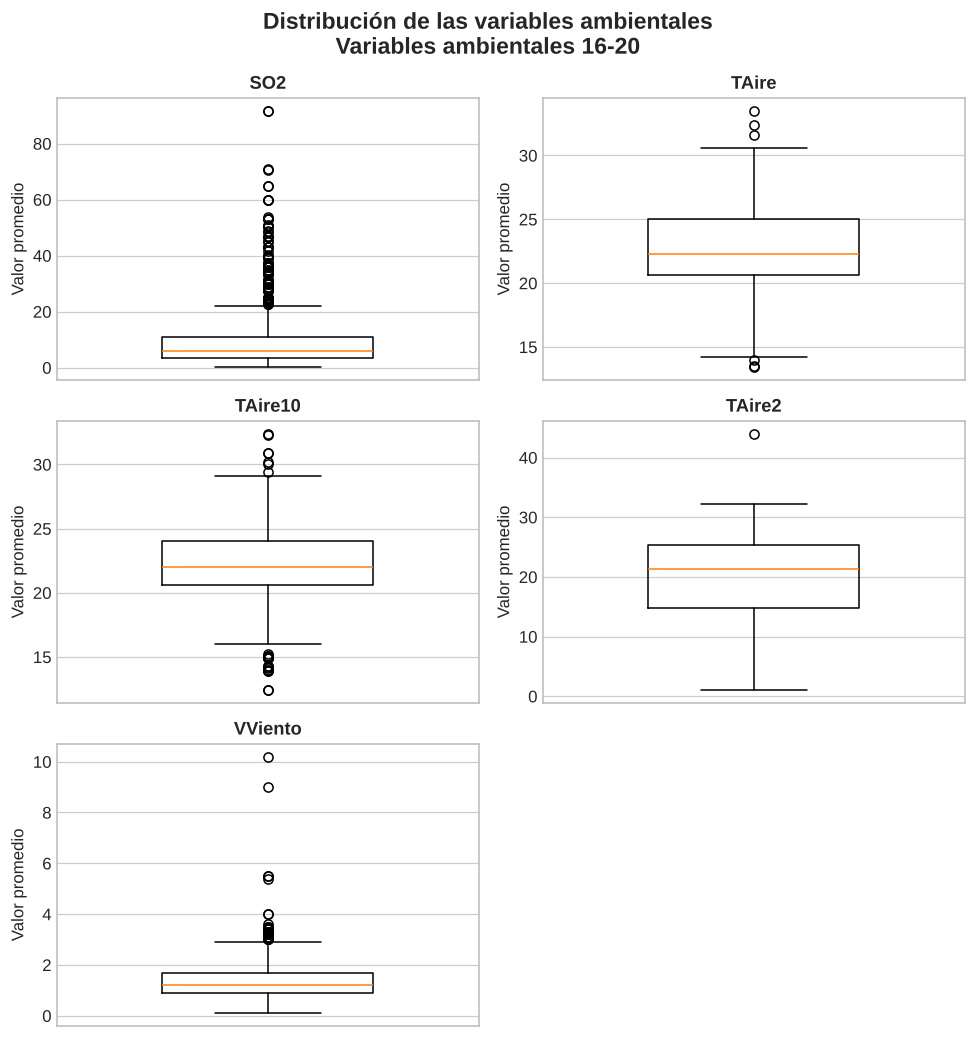

In [29]:
panel_boxplots(15, 20, "Variables ambientales 16-20")

```{admonition} Interpretación
:class: tip
Los diagramas de caja confirman la asimetría: en la mayoría de las variables los puntos aislados aparecen por encima de la caja, no por debajo. RUVb tiene una caja enorme porque mezcla dos escalas de medición distintas (ver sección 1.7).
```

#### Identificación de valores atípicos

In [30]:
outliers_variables = df.groupby("Variable", as_index=False).agg(Q1=("Promedio", lambda s: s.quantile(0.25)), Q3=("Promedio", lambda s: s.quantile(0.75)))
outliers_variables["IQR"] = outliers_variables["Q3"] - outliers_variables["Q1"]
outliers_variables["Limite_inferior"] = outliers_variables["Q1"] - 1.5 * outliers_variables["IQR"]
outliers_variables["Limite_superior"] = outliers_variables["Q3"] + 1.5 * outliers_variables["IQR"]

#### Resumen de valores atípicos

In [31]:
tabla(outliers_variables)

Variable,Q1,Q3,IQR,Limite_inferior,Limite_superior
CO,484.600000,957.200000,472.600000,-224.310000,1666.110000
DViento,83.650000,248.300000,164.650000,-163.330000,495.280000
HAire,62.050000,76.350000,14.300000,40.600000,97.800000
HAire10,65.000000,75.800000,10.800000,48.800000,92.000000
HAire2,66.600000,78.000000,11.400000,49.500000,95.100000
NO,11.750000,34.250000,22.500000,-22.000000,68.000000
NO2,16.500000,35.600000,19.100000,-12.150000,64.250000
O3,19.800000,31.800000,12.000000,1.800000,49.800000
P,629.900000,755.500000,125.600000,441.500000,943.900000
PLiquida,0.200000,3.400000,3.200000,-4.600000,8.200000


```{admonition} Interpretación
:class: tip
Cuando el límite inferior es negativo (CO, NO, NO₂, SO₂, PLiquida) no puede haber atípicos bajos, porque esas variables no toman valores negativos. En esos casos los atípicos son solo valores extremadamente altos.
```

Uso el criterio de Tukey: todo lo que quede por fuera de Q1 menos 1.5 veces el IQR y Q3 más 1.5 veces el IQR lo considero atípico. Es el mismo criterio que apliqué en R.

### 1.4 Representatividad temporal de los datos

In [32]:
representatividad_variables = df.groupby("Variable", as_index=False).agg(Media=("Representatividad Temporal", "mean"), Mediana=("Representatividad Temporal", "median"), Minimo=("Representatividad Temporal", "min"), Maximo=("Representatividad Temporal", "max")).sort_values("Media", ascending=False)
tabla(representatividad_variables)

Variable,Media,Mediana,Minimo,Maximo
P,75.370000,90.000000,0.000000,100.000000
TAire10,73.990000,92.000000,0.000000,100.000000
RUVb,73.740000,89.500000,6.000000,100.000000
CO,72.590000,86.000000,0.000000,100.000000
RGlobal,71.560000,87.000000,0.000000,100.000000
PLiquida,69.800000,89.000000,0.000000,100.000000
DViento,68.590000,86.000000,0.000000,167.000000
HAire10,68.130000,87.000000,0.000000,100.000000
O3,67.620000,80.000000,0.000000,100.000000
NO,66.920000,85.000000,0.000000,100.000000


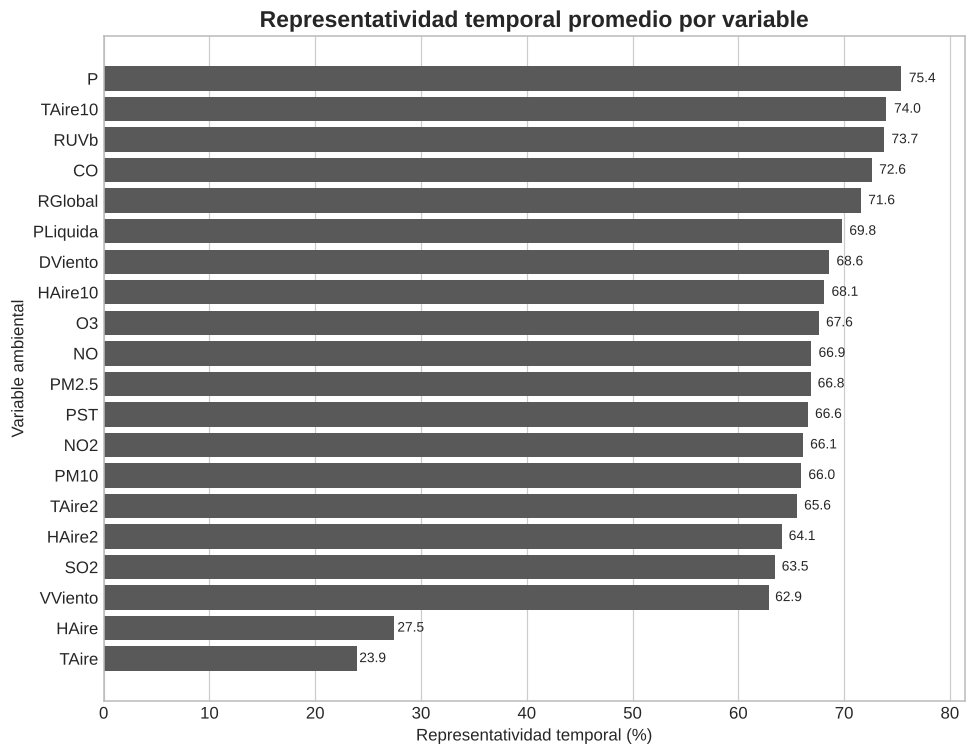

In [33]:
barras_h(representatividad_variables, "Variable", "Media", "Representatividad temporal promedio por variable", "Representatividad temporal (%)", "Variable ambiental", alto=7, dec=1)

```{admonition} Interpretación
:class: tip
Casi todas las variables promedian entre 63 % y 75 % de representatividad: en un registro típico falta cerca de un tercio del año. **TAire y HAire** (sin altura) son la excepción, con 24 % y 27 %: sus promedios anuales se basan en pocos meses.

Solo el 56 % de los registros alcanza el 75 % de cobertura, un umbral comúnmente usado para considerar válido un promedio anual.
```

In [34]:
fuera_de_rango = df[df["Representatividad Temporal"] > 100]
print("Registros con representatividad > 100 %:", len(fuera_de_rango))
print("Máximo reportado:", df["Representatividad Temporal"].max())

Registros con representatividad > 100 %: 12
Máximo reportado: 167.0


```{admonition} Precaución
:class: warning
Una representatividad mayor a 100 % es imposible (no se puede cubrir más que el año completo). Son errores de captura en la fuente; se documentan, pero no se corrigen porque no hay forma de saber el valor real.
```

### 1.5 Distribución geográfica de las estaciones

In [35]:
ubicacion_estaciones = df[["Estación", "Latitud", "Longitud"]].drop_duplicates().sort_values(["Latitud", "Longitud"])
tabla(ubicacion_estaciones.head(20), ["Estación", "Latitud", "Longitud"], decimales=4)

Estación,Latitud,Longitud
IDSN,1.216500,-77.282900
UNIMAR,1.223800,-77.283600
CAMPANARIO,2.438100,-76.613000
EDIFICIO EDGAR NEGRET,2.445200,-76.605400
VIVERO LA FLORIDA,2.476900,-76.566700
VIVERO LA FLORIDA*,2.476900,-76.566700
ALCALDIA,2.928900,-75.289500
CORHUILA,2.930600,-75.264900
CORHUILA,2.930700,-75.265100
CAM NORTE,2.962500,-75.297500


```{admonition} Interpretación
:class: tip
Las estaciones están en todo el país, desde Pasto (latitud 1,2°) hacia el norte. Algunas aparecen repetidas con coordenadas casi idénticas o con un asterisco en el nombre (`VIVERO LA FLORIDA*`): son la misma estación reportada de dos formas.
```

#### Distribución por tipo de estación

In [36]:
frecuencia_tipo_estacion = df["Tipo de Estación"].value_counts().rename_axis("Tipo de Estación").reset_index(name="n")
tabla(frecuencia_tipo_estacion, ["Tipo de estación", "Número de registros"])

Tipo de estación,Número de registros
Fija,14184
Indicativa,1560


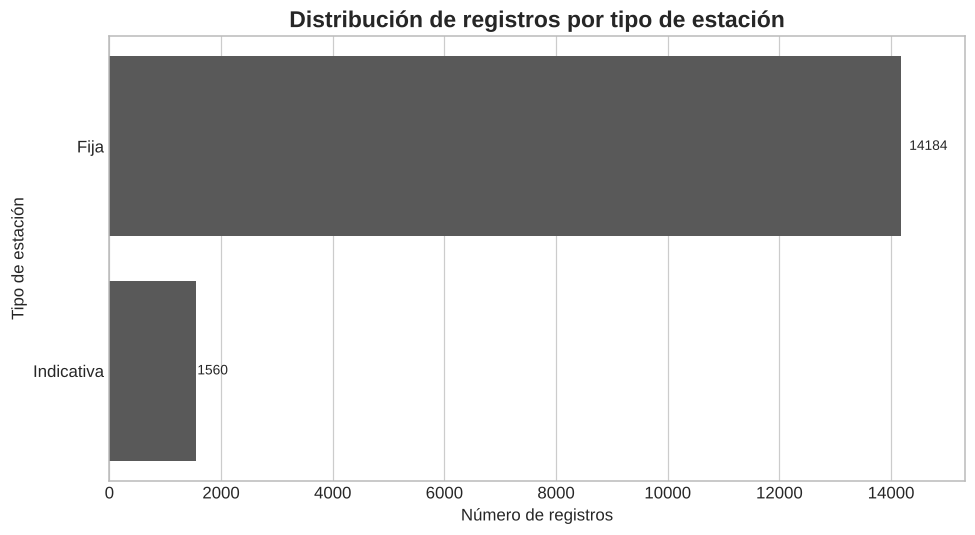

In [37]:
barras_h(frecuencia_tipo_estacion, "Tipo de Estación", "n", "Distribución de registros por tipo de estación", "Número de registros", "Tipo de estación", alto=5)

```{admonition} Interpretación
:class: tip
El 90 % de los registros viene de **estaciones fijas**, que operan de forma continua. Las indicativas son campañas temporales con menos cobertura en el año.
```

#### Distribución por departamento

In [38]:
frecuencia_departamentos = df["Nombre del Departamento"].value_counts().rename_axis("Nombre del Departamento").reset_index(name="n")
tabla(frecuencia_departamentos, ["Departamento", "Número de registros"])

Departamento,Número de registros
ANTIOQUIA,4243
"BOGOTÁ, D.C.",2143
VALLE DEL CAUCA,1434
SANTANDER,940
"BOGOTA, D.C.",840
CUNDINAMARCA,757
CESAR,524
BOYACÁ,515
MAGDALENA,493
"Bogotá, D.C.",410


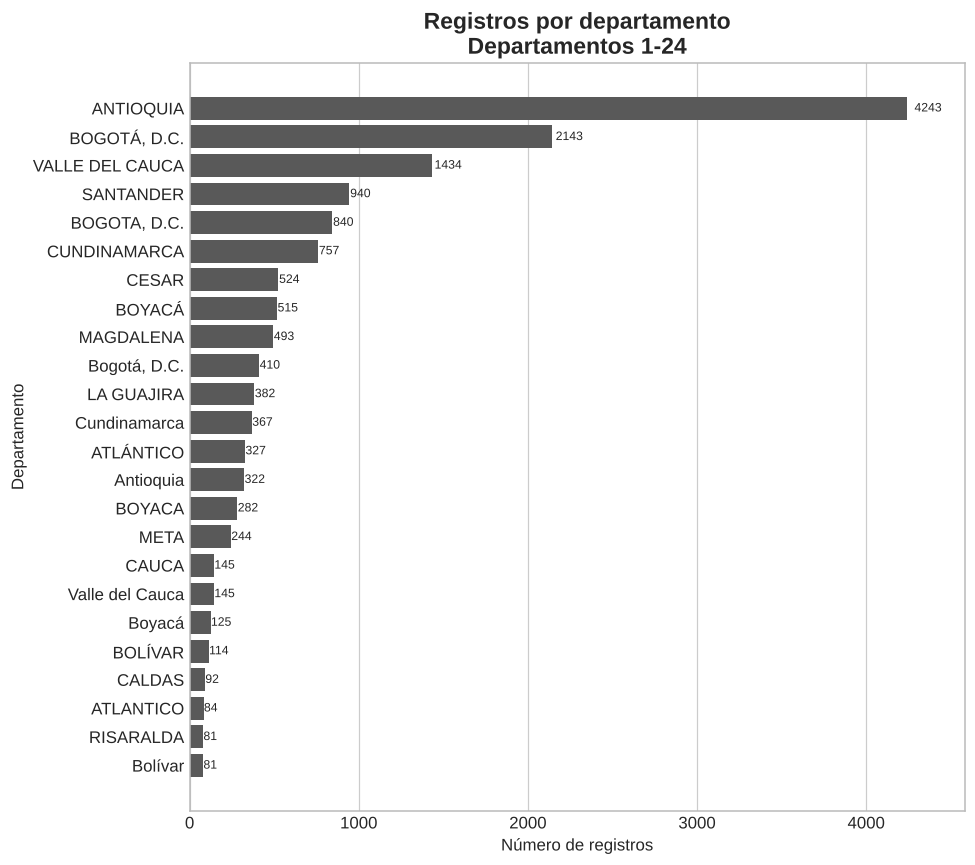

In [39]:
departamentos_1 = frecuencia_departamentos.iloc[0:24]
barras_h(departamentos_1, "Nombre del Departamento", "n", "Registros por departamento", "Número de registros", "Departamento", subtitulo="Departamentos 1-24", alto=8, tam=8)

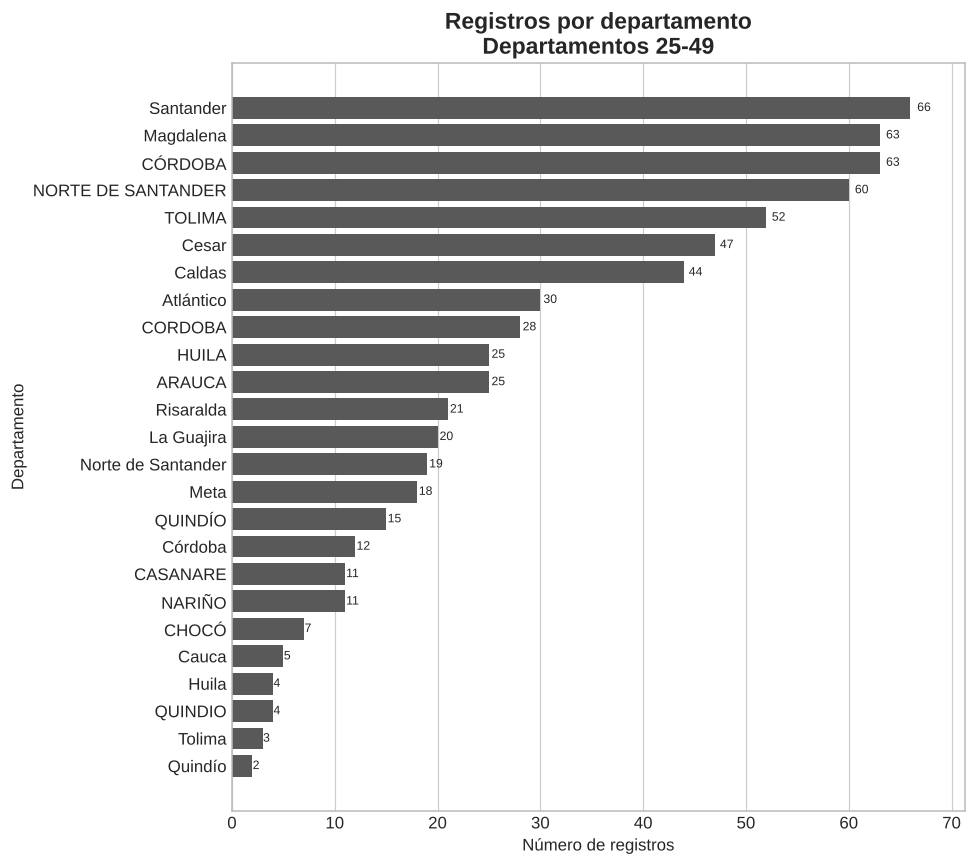

In [40]:
departamentos_2 = frecuencia_departamentos.iloc[24:49]
barras_h(departamentos_2, "Nombre del Departamento", "n", "Registros por departamento", "Número de registros", "Departamento", subtitulo="Departamentos 25-49", alto=8, tam=8)

```{admonition} Precaución
:class: warning
En la tabla anterior el mismo departamento aparece escrito de varias formas: `BOGOTÁ, D.C.`, `BOGOTA, D.C.` y `Bogotá, D.C.`; `ANTIOQUIA` y `Antioquia`, etc. Por eso el conteo da 49 "departamentos". Abajo se normalizan los nombres (sin tildes y en mayúsculas) para obtener el número real.
```

Departamentos:  49 nombres -> 24 reales
Municipios:     339 nombres -> 193 reales


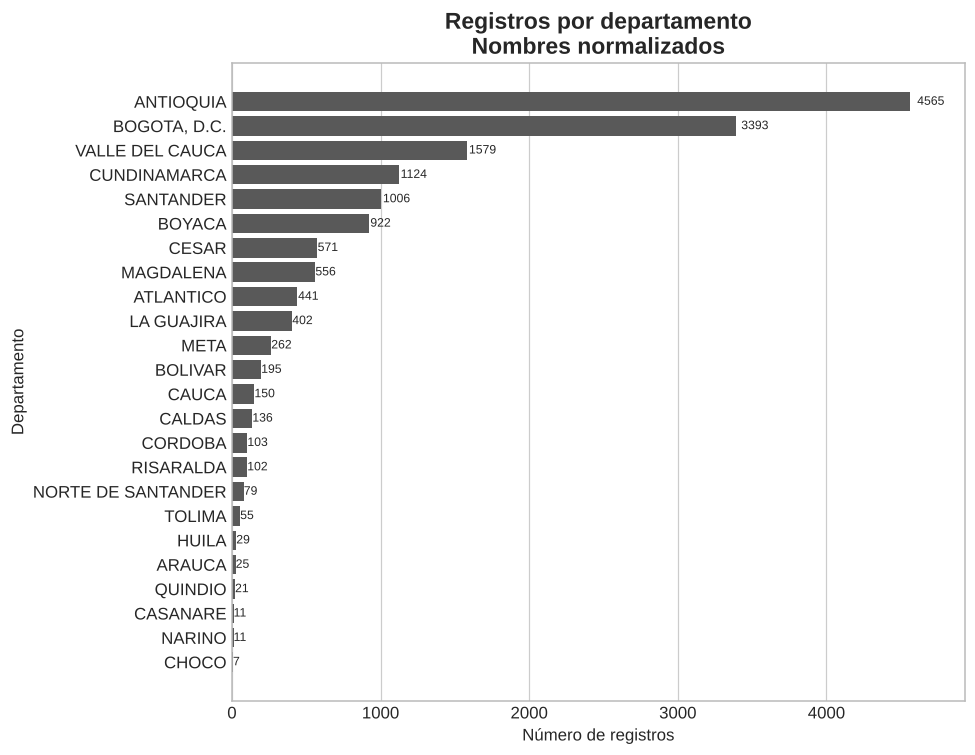

In [41]:
import unicodedata
def normalizar(t):
    t = unicodedata.normalize("NFKD", str(t)).encode("ascii", "ignore").decode()
    return " ".join(t.upper().split())

df["Departamento_norm"] = df["Nombre del Departamento"].map(normalizar)
df["Municipio_norm"] = df["Nombre del Municipio"].map(normalizar)
print("Departamentos: ", df["Nombre del Departamento"].nunique(), "nombres ->", df["Departamento_norm"].nunique(), "reales")
print("Municipios:    ", df["Nombre del Municipio"].nunique(), "nombres ->", df["Municipio_norm"].nunique(), "reales")
deptos_norm = df["Departamento_norm"].value_counts().rename_axis("Departamento").reset_index(name="n")
barras_h(deptos_norm, "Departamento", "n", "Registros por departamento", "Número de registros", "Departamento",
         subtitulo="Nombres normalizados", alto=7, tam=8)

```{admonition} Interpretación
:class: tip
Al normalizar quedan **24 departamentos** (no 49) y **193 municipios** (no 339). Antioquia y Bogotá concentran la mitad de los registros, seguidos por Valle del Cauca y Cundinamarca. La Amazonía, la Orinoquía y gran parte del Pacífico casi no tienen monitoreo: los resultados nacionales representan sobre todo a las ciudades andinas.
```

#### Distribución por municipio

In [42]:
frecuencia_municipios = df["Nombre del Municipio"].value_counts().rename_axis("Nombre del Municipio").reset_index(name="n")
tabla(frecuencia_municipios, ["Municipio", "Número de registros"])

Municipio,Número de registros
"BOGOTÁ, D.C.",2143
CALI,1028
MEDELLÍN,930
"BOGOTA, D.C.",840
BUCARAMANGA,653
SOGAMOSO,446
MEDELLIN,428
GIRARDOTA,414
ITAGÜÍ,395
SANTA MARTA,343


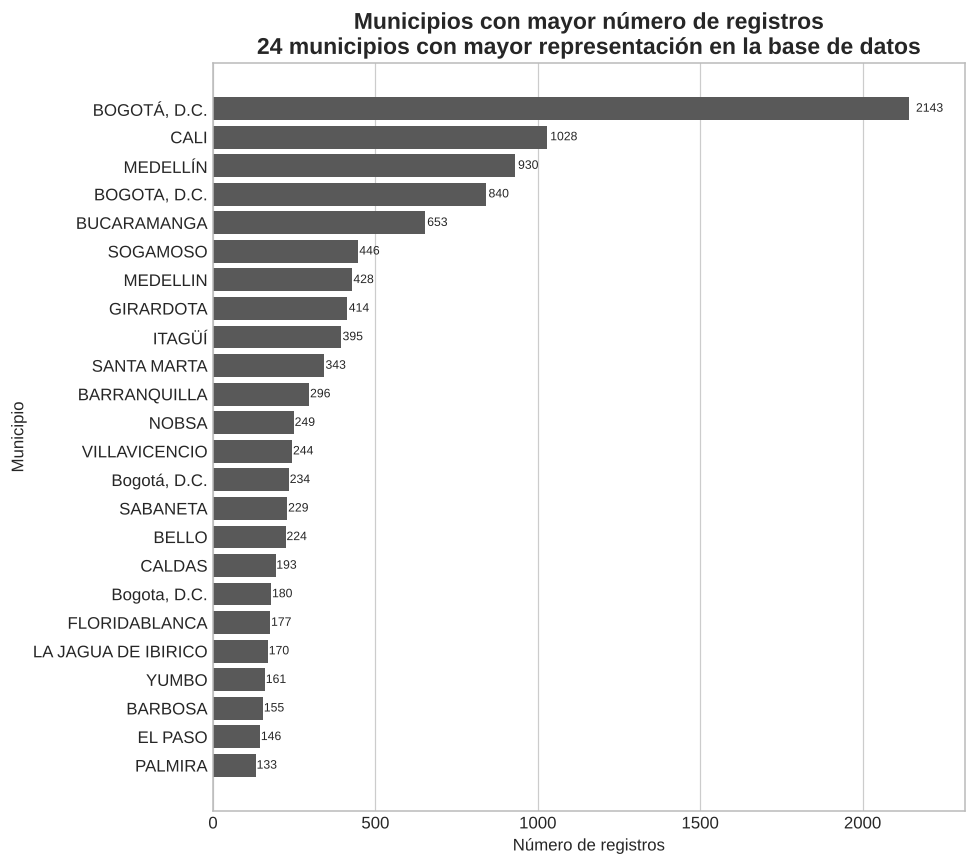

In [43]:
top_municipios = frecuencia_municipios.nlargest(24, "n")
barras_h(top_municipios, "Nombre del Municipio", "n", "Municipios con mayor número de registros", "Número de registros", "Municipio", subtitulo="24 municipios con mayor representación en la base de datos", alto=8, tam=8)

```{admonition} Interpretación
:class: tip
Los municipios con más registros son las capitales con redes de monitoreo grandes: Bogotá, Cali, Medellín y Bucaramanga. Aparecen también municipios industriales o mineros como Sogamoso, Nobsa (cementeras y siderurgia) y La Jagua de Ibirico (carbón), donde la vigilancia responde a fuentes de emisión específicas.
```

### 1.6 Análisis específico de contaminantes

*Objetivo específico 1 · evolución de los contaminantes.*

In [44]:
def estadisticos(serie, con_media=True):
    nombres = ["Mínimo", "Primer cuartil", "Mediana", "Media", "Tercer cuartil", "Máximo"]
    valores = [serie.min(), serie.quantile(0.25), serie.median(), serie.mean(), serie.quantile(0.75), serie.max()]
    if not con_media: nombres, valores = ["Mínimo", "Primer cuartil", "Mediana", "Máximo"], [serie.min(), serie.quantile(0.25), serie.median(), serie.max()]
    return pd.DataFrame({"Estadistico": nombres, "Valor": valores})

def promedio_anual(d, nombre): return d.groupby("Año", as_index=False).agg(**{nombre: ("Promedio", "mean"), "Registros": ("Promedio", "size")}).sort_values("Año").reset_index(drop=True)

def grafico_anual(d, col, titulo, subtitulo, ylab, anios=None):
    fig, ax = plt.subplots()
    ax.plot(d["Año"], d[col], linewidth=1.2, marker="o", markersize=6, color="black")
    for x, y in zip(d["Año"], d[col]): ax.text(x, y + (d[col].max() - d[col].min() + 1) * 0.03, f"{y:.1f}", ha="center", fontsize=9)
    ax.set_xticks(list(anios) if anios is not None else sorted(d["Año"].unique()))
    ax.set_ylim(top=d[col].max() * 1.08)
    ax.set_title(titulo + "\n" + subtitulo, fontweight="bold"); ax.set_xlabel("Año"); ax.set_ylabel(ylab)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

def cambio_porcentual(d, col, a1=2011, a2=2024):
    s = d.set_index("Año")[col]
    if a1 not in s.index or a2 not in s.index: return pd.DataFrame({"Periodo": ["N/A"], "Promedio_2011": [np.nan], "Promedio_2024": [np.nan], "Cambio_porcentual": [np.nan]})
    v1, v2 = s.loc[a1], s.loc[a2]
    return pd.DataFrame({"Periodo": [f"{a1}-{a2}"], "Promedio_2011": [v1], "Promedio_2024": [v2], "Cambio_porcentual": [(v2 - v1) / v1 * 100]})

#### PM10

In [45]:
pm10 = df[df["Variable"] == "PM10"].copy()
print("Registros de PM10:", len(pm10))
estadistica_pm10 = estadisticos(pm10["Promedio"])
tabla(estadistica_pm10, ["Estadístico", "Valor"])

Registros de PM10: 2984


Estadístico,Valor
Mínimo,4.600000
Primer cuartil,27.000000
Mediana,34.600000
Media,37.130000
Tercer cuartil,44.800000
Máximo,162.300000


```{admonition} Interpretación
:class: tip
PM10 tiene 2.984 registros. La media (37,1 µg/m³) es algo mayor que la mediana (34,6 µg/m³), lo que indica asimetría positiva: algunas estaciones con valores altos, como el máximo de 162,3 µg/m³, elevan el promedio.
```

In [46]:
pm10_anual = promedio_anual(pm10, "Promedio_PM10")
tabla(pm10_anual, ["Año", "Promedio PM10", "Número de registros"])

Año,Promedio PM10,Número de registros
2011,42.660000,143
2012,44.600000,162
2013,42.070000,161
2014,43.640000,164
2015,44.400000,182
2016,43.650000,177
2017,37.700000,227
2018,37.030000,221
2019,35.780000,211
2020,35.900000,267


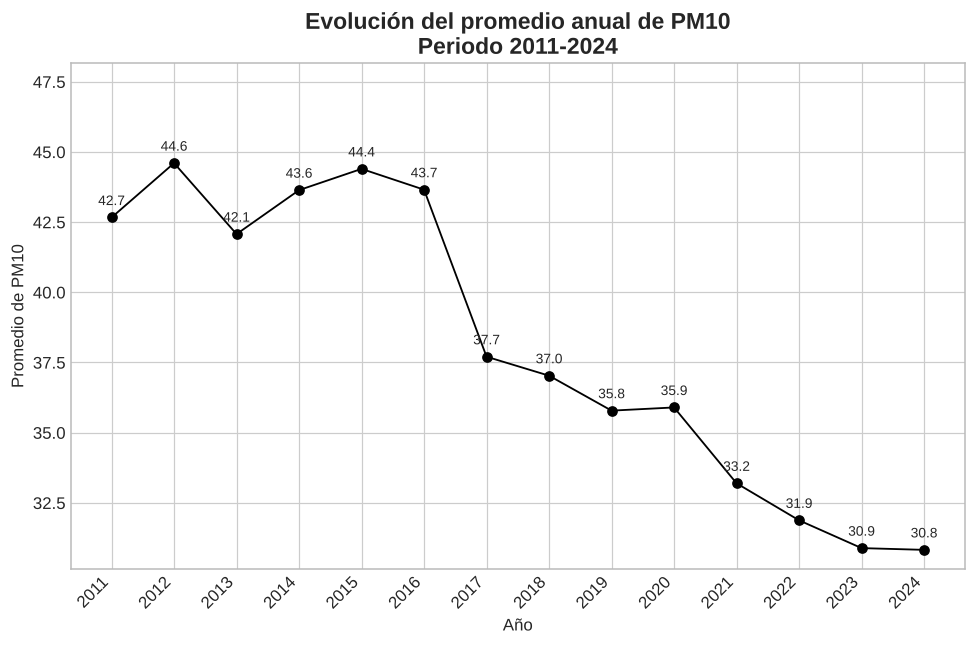

In [47]:
grafico_anual(pm10_anual, "Promedio_PM10", "Evolución del promedio anual de PM10", "Periodo 2011-2024", "Promedio de PM10", anios=range(2011, 2025))

```{admonition} Interpretación
:class: tip
El PM10 se mantuvo cerca de 43–44 µg/m³ entre 2011 y 2016 y desde 2017 baja de forma sostenida hasta 30,8 µg/m³ en 2024. Es la tendencia más estable de todos los contaminantes.

Como referencia, la Resolución 2254 de 2017 fija un nivel anual de 50 µg/m³ y una meta de 30 µg/m³ a 2030: el promedio nacional estuvo por debajo del nivel vigente todos los años y en 2024 quedó muy cerca de la meta futura. Es solo una referencia, porque el promedio mezcla registros de 1 y 24 horas de exposición.
```

In [48]:
tabla_cambio_pm10 = cambio_porcentual(pm10_anual, "Promedio_PM10")
tabla(tabla_cambio_pm10, ["Periodo", "Promedio 2011", "Promedio 2024", "Cambio (%)"])

Periodo,Promedio 2011,Promedio 2024,Cambio (%)
2011-2024,42.660000,30.830000,-27.750000


```{admonition} Interpretación
:class: tip
Entre 2011 y 2024 el PM10 bajó **27,75 %**.
```

#### PM2.5

In [49]:
pm25 = df[df["Variable"] == "PM2.5"].copy()
print("Registros de PM2.5:", len(pm25))
estadistica_pm25 = estadisticos(pm25["Promedio"])
tabla(estadistica_pm25, ["Estadístico", "Valor"])

Registros de PM2.5: 1984


Estadístico,Valor
Mínimo,2.700000
Primer cuartil,12.500000
Mediana,15.700000
Media,16.840000
Tercer cuartil,19.800000
Máximo,68.600000


```{admonition} Interpretación
:class: tip
El PM2.5 tiene menos registros (1.984) y valores más bajos que el PM10, lo esperable porque es la fracción fina del material particulado. La media (16,8 µg/m³) y la mediana (15,7 µg/m³) son cercanas.
```

In [50]:
pm25_anual = promedio_anual(pm25, "Promedio_PM25")
tabla(pm25_anual, ["Año", "Promedio PM2.5", "Número de registros"])

Año,Promedio PM2.5,Número de registros
2011,21.460000,19
2012,23.880000,33
2013,22.160000,40
2014,21.480000,55
2015,22.390000,59
2016,23.680000,65
2017,18.580000,142
2018,16.530000,162
2019,18.510000,139
2020,16.980000,233


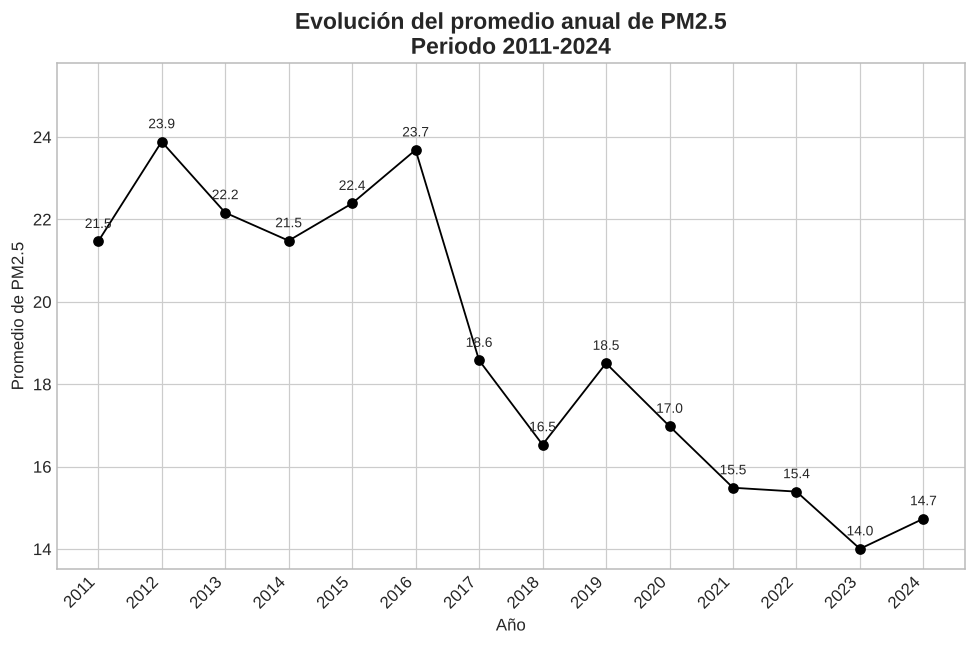

In [51]:
grafico_anual(pm25_anual, "Promedio_PM25", "Evolución del promedio anual de PM2.5", "Periodo 2011-2024", "Promedio de PM2.5", anios=range(2011, 2025))

```{admonition} Interpretación
:class: tip
El PM2.5 cae con fuerza en 2017, de 23,7 a 18,6 µg/m³. Ese salto coincide con que el número de registros se duplicó (de 65 a 142): al entrar estaciones nuevas, posiblemente en zonas menos contaminadas, el promedio puede bajar sin que el aire haya mejorado en las estaciones existentes. Es un **efecto de composición de la red** que este EDA no puede descartar.

Desde 2023 el promedio nacional (14,0–14,7 µg/m³) está por debajo de la meta a 2030 de la Res. 2254/2017 (15 µg/m³).
```

In [52]:
tabla_cambio_pm25 = cambio_porcentual(pm25_anual, "Promedio_PM25")
tabla(tabla_cambio_pm25, ["Periodo", "Promedio 2011", "Promedio 2024", "Cambio (%)"])

Periodo,Promedio 2011,Promedio 2024,Cambio (%)
2011-2024,21.460000,14.730000,-31.350000


```{admonition} Interpretación
:class: tip
Entre 2011 y 2024 el PM2.5 bajó **31,35 %**.
```

#### NO₂

In [53]:
no2 = df[df["Variable"] == "NO2"].copy()
print("Registros de NO2:", len(no2))
estadistica_no2 = estadisticos(no2["Promedio"])
tabla(estadistica_no2, ["Estadístico", "Valor"])

Registros de NO2: 644


Estadístico,Valor
Mínimo,0.500000
Primer cuartil,16.500000
Mediana,26.000000
Media,26.460000
Tercer cuartil,35.600000
Máximo,65.600000


```{admonition} Interpretación
:class: tip
El NO₂ tiene solo 644 registros: entre 20 y 59 por año. La media (26,5 µg/m³) y la mediana (26,0 µg/m³) son prácticamente iguales, una distribución bastante simétrica.
```

In [54]:
no2_anual = promedio_anual(no2, "Promedio_NO2")
tabla(no2_anual, ["Año", "Promedio NO2", "Número de registros"])

Año,Promedio NO2,Número de registros
2011,36.280000,40
2012,31.770000,48
2013,30.520000,43
2014,24.850000,49
2015,24.360000,53
2016,28.280000,48
2017,21.320000,59
2018,24.270000,30
2019,23.320000,20
2020,24.390000,49


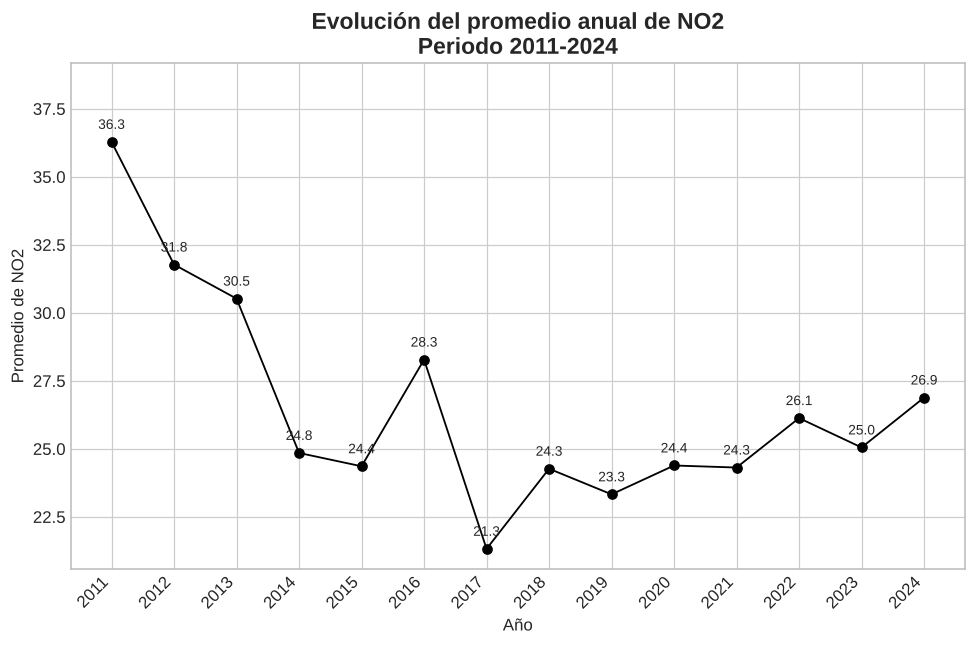

In [55]:
grafico_anual(no2_anual, "Promedio_NO2", "Evolución del promedio anual de NO2", "Periodo 2011-2024", "Promedio de NO2", anios=range(2011, 2025))

```{admonition} Interpretación
:class: tip
El NO₂ bajó con fuerza entre 2011 y 2017 (de 36,3 a 21,3 µg/m³), pero desde entonces sube lentamente hasta 26,9 µg/m³ en 2024. El cambio total esconde ese repunte. El NO₂ proviene sobre todo de la combustión vehicular, así que el repunte podría reflejar el aumento del parque automotor. Todos los valores están muy por debajo del nivel anual vigente (60 µg/m³) y de la meta 2030 (40 µg/m³).
```

In [56]:
tabla_cambio_no2 = cambio_porcentual(no2_anual, "Promedio_NO2")
tabla(tabla_cambio_no2, ["Periodo", "Promedio 2011", "Promedio 2024", "Cambio (%)"])

Periodo,Promedio 2011,Promedio 2024,Cambio (%)
2011-2024,36.280000,26.880000,-25.900000


```{admonition} Interpretación
:class: tip
Entre 2011 y 2024 el NO₂ bajó **25,9 %**, pero con el repunte desde 2017 descrito arriba.
```

#### O₃

In [57]:
o3 = df[df["Variable"] == "O3"].copy()
print("Registros de O3:", len(o3))
estadistica_o3 = estadisticos(o3["Promedio"])
tabla(estadistica_o3, ["Estadístico", "Valor"])

Registros de O3: 827


Estadístico,Valor
Mínimo,2.000000
Primer cuartil,19.800000
Mediana,25.700000
Media,26.150000
Tercer cuartil,31.800000
Máximo,65.800000


```{admonition} Interpretación
:class: tip
El ozono tiene 827 registros, con media y mediana cercanas (26,2 y 25,7 µg/m³).
```

In [58]:
o3_anual = promedio_anual(o3, "Promedio_O3")
tabla(o3_anual, ["Año", "Promedio O3", "Número de registros"])

Año,Promedio O3,Número de registros
2011,23.940000,40
2012,27.550000,58
2013,27.860000,54
2014,29.010000,58
2015,32.640000,66
2016,26.740000,70
2017,24.230000,107
2018,23.940000,48
2019,25.000000,35
2020,25.920000,55


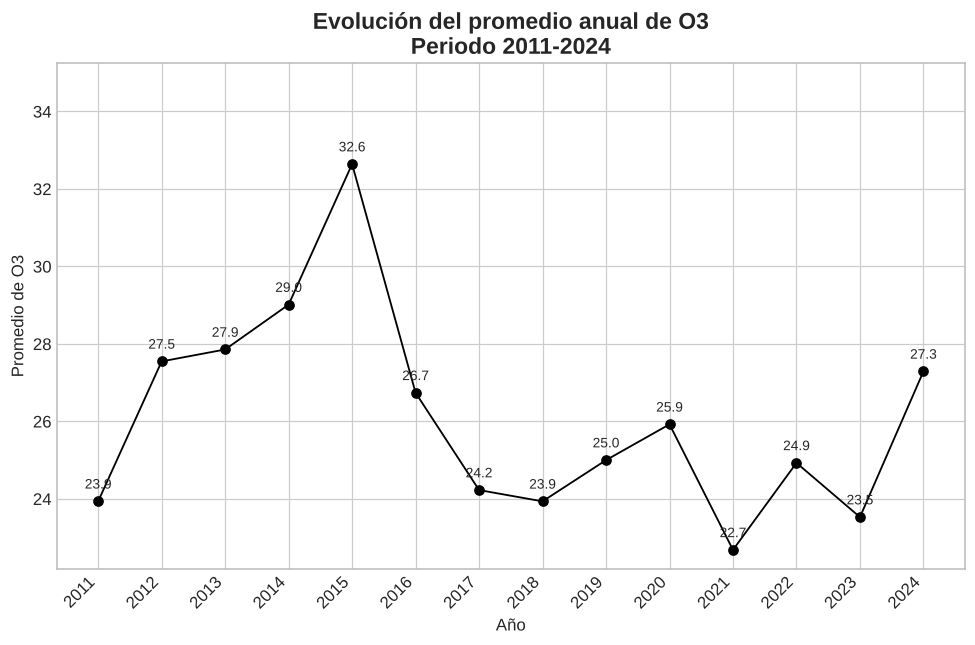

In [59]:
grafico_anual(o3_anual, "Promedio_O3", "Evolución del promedio anual de O3", "Periodo 2011-2024", "Promedio de O3", anios=range(2011, 2025))

```{admonition} Interpretación
:class: tip
El ozono no muestra una tendencia clara: sube hasta 32,6 µg/m³ en 2015, baja hasta 22,7 µg/m³ en 2021 y vuelve a subir en 2024. El O₃ no se emite directamente: se forma en la atmósfera a partir de óxidos de nitrógeno y compuestos orgánicos con la radiación solar. Por eso puede subir aunque bajen otros contaminantes.
```

In [60]:
tabla_cambio_o3 = cambio_porcentual(o3_anual, "Promedio_O3")
tabla(tabla_cambio_o3, ["Periodo", "Promedio 2011", "Promedio 2024", "Cambio (%)"])

Periodo,Promedio 2011,Promedio 2024,Cambio (%)
2011-2024,23.940000,27.290000,14.000000


```{admonition} Interpretación
:class: tip
El ozono es el único contaminante que **aumentó** entre 2011 y 2024 (+14 %).
```

#### SO₂

In [61]:
so2 = df[df["Variable"] == "SO2"].copy()
print("Registros de SO2:", len(so2))
estadistica_so2 = estadisticos(so2["Promedio"])
tabla(estadistica_so2, ["Estadístico", "Valor"])

Registros de SO2: 1066


Estadístico,Valor
Mínimo,0.100000
Primer cuartil,3.400000
Mediana,6.000000
Media,9.430000
Tercer cuartil,11.000000
Máximo,91.710000


```{admonition} Interpretación
:class: tip
El SO₂ es muy asimétrico: la media (9,4 µg/m³) es mucho mayor que la mediana (6,0 µg/m³) y el máximo llega a 91,7 µg/m³. Unas pocas estaciones cercanas a fuentes industriales concentran los valores altos.
```

In [62]:
so2_anual = promedio_anual(so2, "Promedio_SO2")
tabla(so2_anual, ["Año", "Promedio SO2", "Número de registros"])

Año,Promedio SO2,Número de registros
2011,15.140000,43
2012,11.260000,39
2013,6.840000,39
2014,5.920000,33
2015,7.260000,36
2016,15.920000,52
2017,10.350000,96
2018,8.340000,60
2019,9.800000,70
2020,8.710000,113


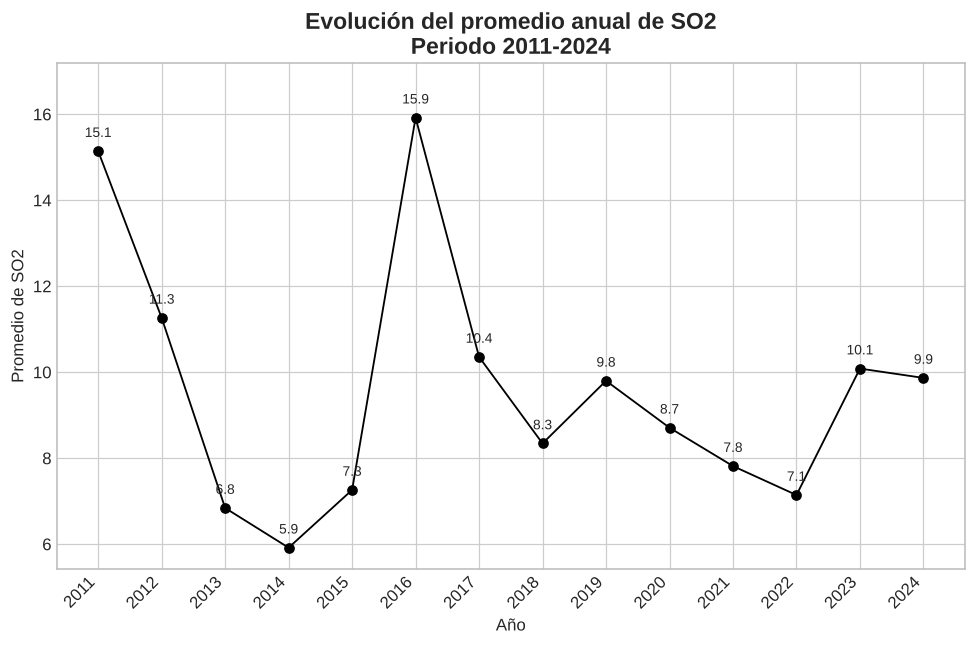

In [63]:
grafico_anual(so2_anual, "Promedio_SO2", "Evolución del promedio anual de SO2", "Periodo 2011-2024", "Promedio de SO2", anios=range(2011, 2025))

```{admonition} Interpretación
:class: tip
La serie del SO₂ es muy irregular: baja a 5,9 µg/m³ en 2014 y sube a 15,9 µg/m³ en 2016. Ese comportamiento de sierra sugiere que el promedio depende de pocas estaciones industriales que entran y salen de la red.
```

In [64]:
tabla_cambio_so2 = cambio_porcentual(so2_anual, "Promedio_SO2")
tabla(tabla_cambio_so2, ["Periodo", "Promedio 2011", "Promedio 2024", "Cambio (%)"])

Periodo,Promedio 2011,Promedio 2024,Cambio (%)
2011-2024,15.140000,9.860000,-34.840000


```{admonition} Interpretación
:class: tip
La caída de **34,8 %** es la mayor de los cinco contaminantes, pero por la irregularidad de la serie no debe leerse como una mejora clara y sostenida.
```

#### Comparación del cambio porcentual de los contaminantes

In [65]:
cambios = []
for nombre, dat in [("PM10", pm10_anual), ("PM2.5", pm25_anual), ("NO2", no2_anual), ("O3", o3_anual), ("SO2", so2_anual)]:
    s = dat.set_index("Año").iloc[:, 0]
    if 2011 in s.index and 2024 in s.index:
        v1, v2 = s.loc[2011], s.loc[2024]
        cambios.append({"Contaminante": nombre, "Promedio_2011": v1, "Promedio_2024": v2, "Cambio_porcentual": (v2 - v1) / v1 * 100})
comparacion_contaminantes = pd.DataFrame(cambios)
tabla(comparacion_contaminantes, ["Contaminante", "Promedio 2011", "Promedio 2024", "Cambio (%)"])

Contaminante,Promedio 2011,Promedio 2024,Cambio (%)
PM10,42.660000,30.830000,-27.750000
PM2.5,21.460000,14.730000,-31.350000
NO2,36.280000,26.880000,-25.900000
O3,23.940000,27.290000,14.000000
SO2,15.140000,9.860000,-34.840000


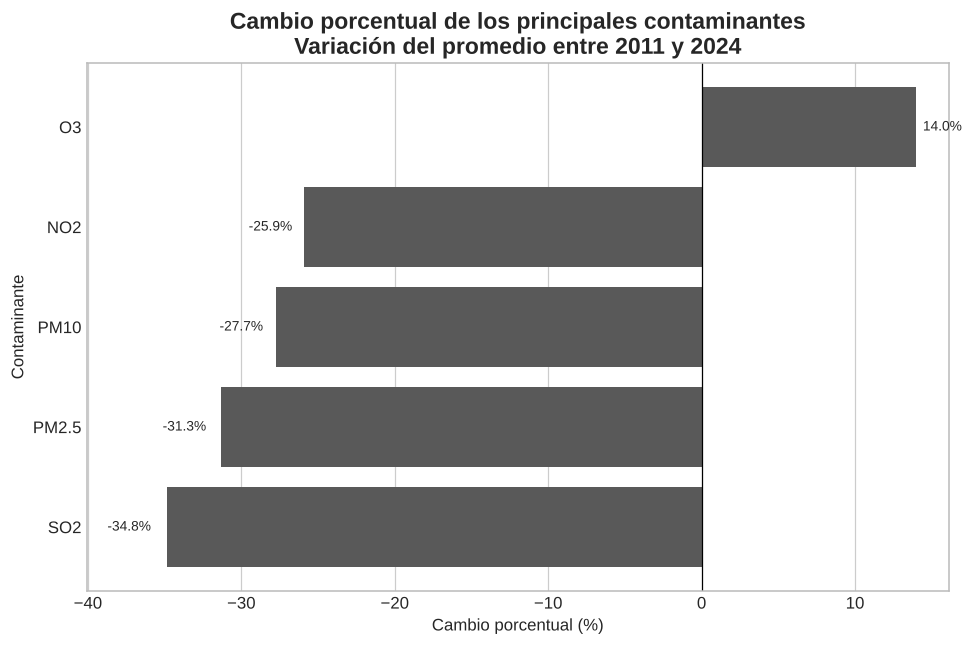

In [66]:
d = comparacion_contaminantes.sort_values("Cambio_porcentual")
fig, ax = plt.subplots()
ax.barh(d["Contaminante"], d["Cambio_porcentual"], color="#595959")
for y, v in zip(d["Contaminante"], d["Cambio_porcentual"]): ax.text(v * 1.03, y, f"{v:.1f}%", va="center", ha="right" if v < 0 else "left", fontsize=9)
ax.set_xlim(d["Cambio_porcentual"].min() * 1.15, d["Cambio_porcentual"].max() * 1.15)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Cambio porcentual de los principales contaminantes\nVariación del promedio entre 2011 y 2024", fontweight="bold")
ax.set_xlabel("Cambio porcentual (%)"); ax.set_ylabel("Contaminante"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
Cuatro de los cinco contaminantes bajaron entre 2011 y 2024, y el material particulado, el más relevante para la salud, se redujo cerca de 30 %. El ozono es la excepción.

El tamaño del cambio no indica qué tan confiable es: el SO₂ tiene la mayor caída pero la serie más irregular, y el PM10 una caída menor pero la tendencia más estable.
```

### 1.7 Análisis de variables meteorológicas

*Objetivo específico 1 · variables meteorológicas.*

#### Temperatura del aire (TAire)

In [67]:
taire = df[df["Variable"] == "TAire"].copy()
print("Registros de TAire:", len(taire))
estadistica_taire = estadisticos(taire["Promedio"])
tabla(estadistica_taire, ["Estadístico", "Valor"])

Registros de TAire: 73


Estadístico,Valor
Mínimo,13.400000
Primer cuartil,20.600000
Mediana,22.300000
Media,22.620000
Tercer cuartil,25.000000
Máximo,33.500000


In [68]:
taire_anual = promedio_anual(taire, "Promedio_TAire")
tabla(taire_anual, ["Año", "Promedio TAire", "Número de registros"])

Año,Promedio TAire,Número de registros
2011,20.900000,2
2012,21.970000,6
2013,22.080000,8
2017,22.310000,34
2018,23.120000,17
2019,24.880000,6


```{admonition} Interpretación
:class: tip
TAire solo tiene datos en 6 años (2011–2013 y 2017–2019) y 73 registros; algunos años tienen apenas 2.
```

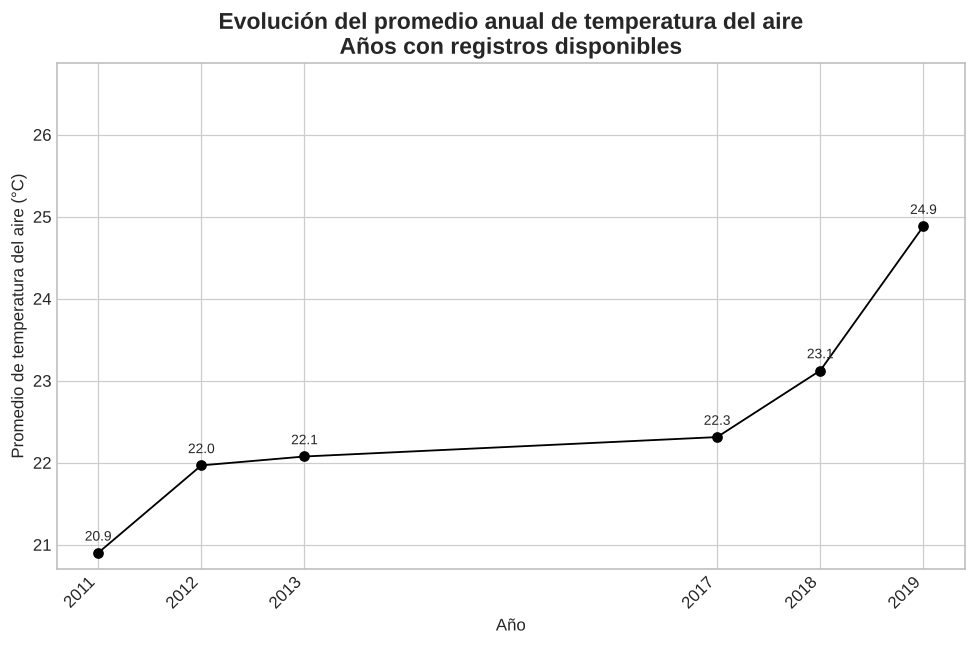

In [69]:
grafico_anual(taire_anual, "Promedio_TAire", "Evolución del promedio anual de temperatura del aire", "Años con registros disponibles", "Promedio de temperatura del aire (°C)")

```{admonition} Interpretación
:class: tip
La subida de 20,9 °C a 24,9 °C no es un cambio climático plausible en 8 años: refleja que cambiaron las estaciones que reportan (una estación en tierra caliente sube el promedio). TAire2 y TAire10, con 834 y 334 registros, son mejores variables para estudiar la temperatura.
```

#### Humedad relativa del aire (HAire)

In [70]:
haire = df[df["Variable"] == "HAire"].copy()
print("Registros de HAire:", len(haire))
estadistica_haire = estadisticos(haire["Promedio"])
tabla(estadistica_haire, ["Estadístico", "Valor"])

Registros de HAire: 75


Estadístico,Valor
Mínimo,33.100000
Primer cuartil,62.050000
Mediana,71.800000
Media,66.090000
Tercer cuartil,76.350000
Máximo,92.000000


In [71]:
haire_anual = promedio_anual(haire, "Promedio_HAire")
tabla(haire_anual, ["Año", "Promedio HAire", "Número de registros"])

Año,Promedio HAire,Número de registros
2011,71.900000,4
2012,70.700000,2
2013,72.550000,2
2014,68.340000,5
2017,65.510000,36
2018,62.390000,20
2019,72.530000,6


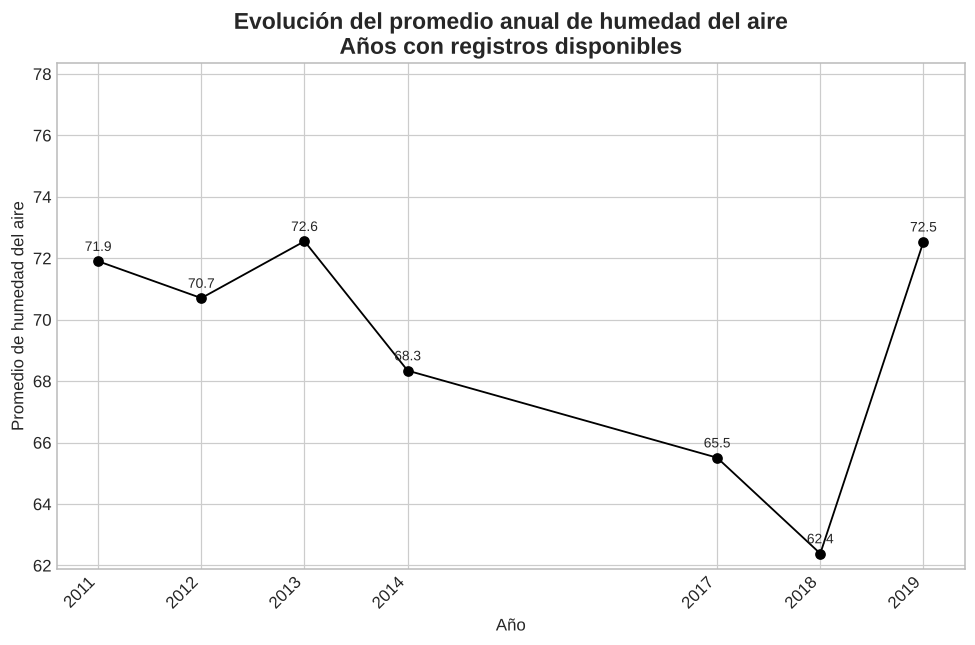

In [72]:
grafico_anual(haire_anual, "Promedio_HAire", "Evolución del promedio anual de humedad del aire", "Años con registros disponibles", "Promedio de humedad del aire")

```{admonition} Interpretación
:class: tip
La humedad relativa oscila entre 62 % y 73 % sin una tendencia clara. Con solo 7 años y 75 registros, y 27 % de representatividad media, sus promedios anuales son poco confiables.
```

#### Velocidad del viento (VViento)

In [73]:
vviento = df[df["Variable"] == "VViento"].copy()
print("Registros de VViento:", len(vviento))
estadistica_vviento = estadisticos(vviento["Promedio"])
tabla(estadistica_vviento, ["Estadístico", "Valor"])

Registros de VViento: 1254


Estadístico,Valor
Mínimo,0.100000
Primer cuartil,0.900000
Mediana,1.200000
Media,1.370000
Tercer cuartil,1.700000
Máximo,10.200000


In [74]:
vviento_anual = promedio_anual(vviento, "Promedio_VViento")
tabla(vviento_anual, ["Año", "Promedio VViento", "Número de registros"])

Año,Promedio VViento,Número de registros
2011,1.410000,52
2012,1.560000,61
2013,1.690000,89
2014,1.600000,89
2015,1.450000,91
2016,1.230000,100
2017,1.260000,115
2018,1.470000,89
2019,1.390000,74
2020,1.310000,136


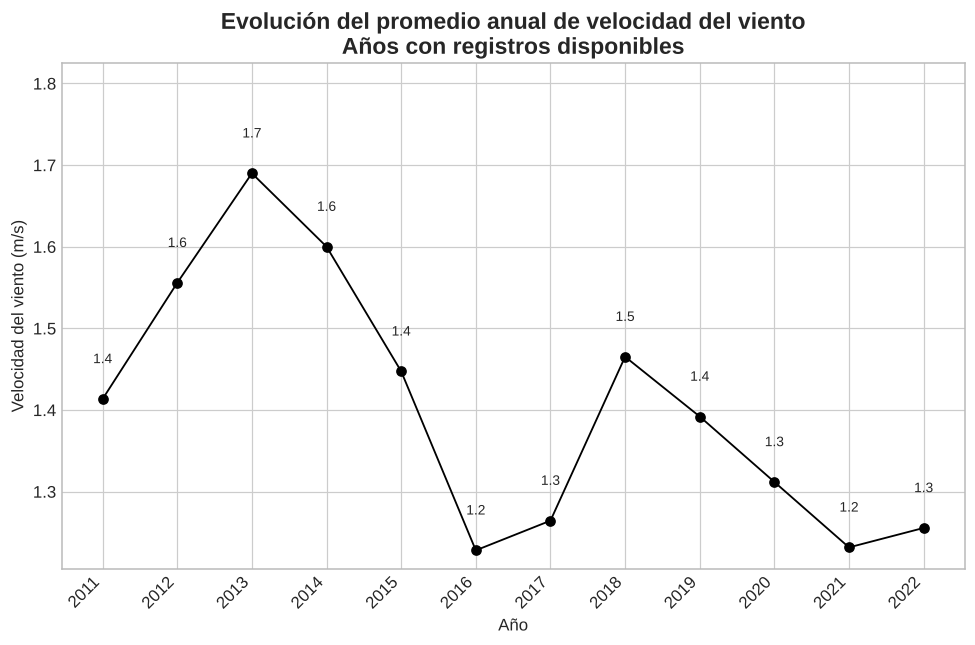

In [75]:
grafico_anual(vviento_anual, "Promedio_VViento", "Evolución del promedio anual de velocidad del viento", "Años con registros disponibles", "Velocidad del viento (m/s)")

```{admonition} Interpretación
:class: tip
La velocidad del viento es baja en todo el periodo (1,2–1,7 m/s), en el rango de vientos débiles, y desde 2013 baja levemente. Con poco viento los contaminantes se dispersan menos, sobre todo en valles cerrados como el Aburrá, donde está buena parte de las estaciones.
```

#### Presión atmosférica (P)

In [76]:
presion = df[df["Variable"] == "P"].copy()
print("Registros de P:", len(presion))
estadistica_presion = estadisticos(presion["Promedio"])
tabla(estadistica_presion, ["Estadístico", "Valor"])

Registros de P: 673


Estadístico,Valor
Mínimo,399.100000
Primer cuartil,629.900000
Mediana,677.600000
Media,701.680000
Tercer cuartil,755.500000
Máximo,1010.400000


In [77]:
presion_anual = promedio_anual(presion, "Promedio_P")
tabla(presion_anual, ["Año", "Promedio de presión", "Número de registros"])

Año,Promedio de presión,Número de registros
2011,634.880000,23
2012,636.120000,31
2013,631.590000,30
2014,639.330000,32
2015,651.300000,41
2016,726.740000,40
2017,753.810000,54
2018,851.040000,50
2019,843.070000,31
2020,719.270000,95


```{admonition} Interpretación
:class: tip
La presión salta de unos 635 mmHg (2011–2014) a 851 mmHg en 2018. La presión a nivel del mar es 760 mmHg y en Bogotá cerca de 560 mmHg, así que un promedio superior a 800 mmHg es **físicamente imposible**. La celda siguiente revela la causa.
```

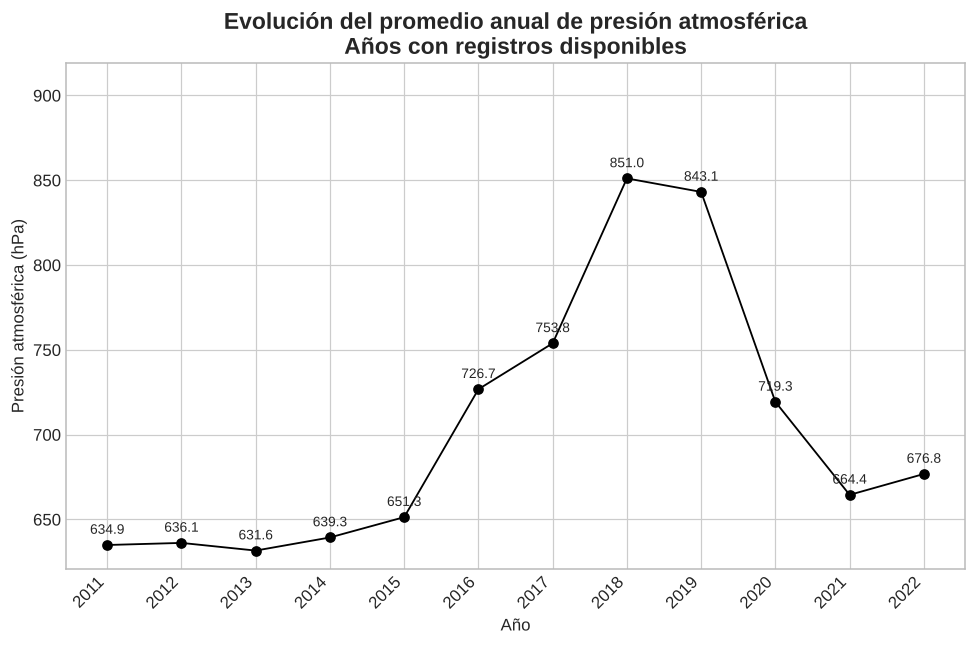

In [78]:
grafico_anual(presion_anual, "Promedio_P", "Evolución del promedio anual de presión atmosférica", "Años con registros disponibles", "Presión atmosférica (hPa)")

In [79]:
sospechosos = presion[presion["Promedio"] > 800]
print("Registros de presión > 800 mmHg:", len(sospechosos), "de", len(presion))
sospechosos["Nombre del Municipio"].value_counts().head(6)

Registros de presión > 800 mmHg: 108 de 673


Nombre del Municipio
CALI             22
VILLAVICENCIO    18
BARRANQUILLA     18
SANTA MARTA       8
MEDELLÍN          8
GIRARDOTA         6
Name: count, dtype: int64

```{admonition} Precaución
:class: warning
Hay registros de más de 800 mmHg en Cali y Medellín, ciudades a 1.000–1.500 m de altitud, donde la presión real ronda 640–680 mmHg. Los valores cercanos a 1.010 corresponden a **hectopascales (hPa)** etiquetados como mmHg. Es un error de unidades: esta variable no se puede interpretar ni correlacionar sin corregirlo.
```

#### Precipitación líquida (PLiquida)

In [80]:
pliquida = df[df["Variable"] == "PLiquida"].copy()
print("Registros de PLiquida:", len(pliquida))
estadistica_pliquida = estadisticos(pliquida["Promedio"])
tabla(estadistica_pliquida, ["Estadístico", "Valor"])

Registros de PLiquida: 927


Estadístico,Valor
Mínimo,0.100000
Primer cuartil,0.200000
Mediana,1.400000
Media,9.770000
Tercer cuartil,3.400000
Máximo,3236.700000


In [81]:
pliquida_anual = promedio_anual(pliquida, "Promedio_PLiquida")
tabla(pliquida_anual, ["Año", "Promedio de precipitación", "Número de registros"])

Año,Promedio de precipitación,Número de registros
2011,3.290000,58
2012,1.950000,66
2013,2.580000,77
2014,3.060000,61
2015,2.130000,70
2016,4.560000,84
2017,56.530000,63
2018,2.970000,60
2019,34.790000,45
2020,16.460000,89


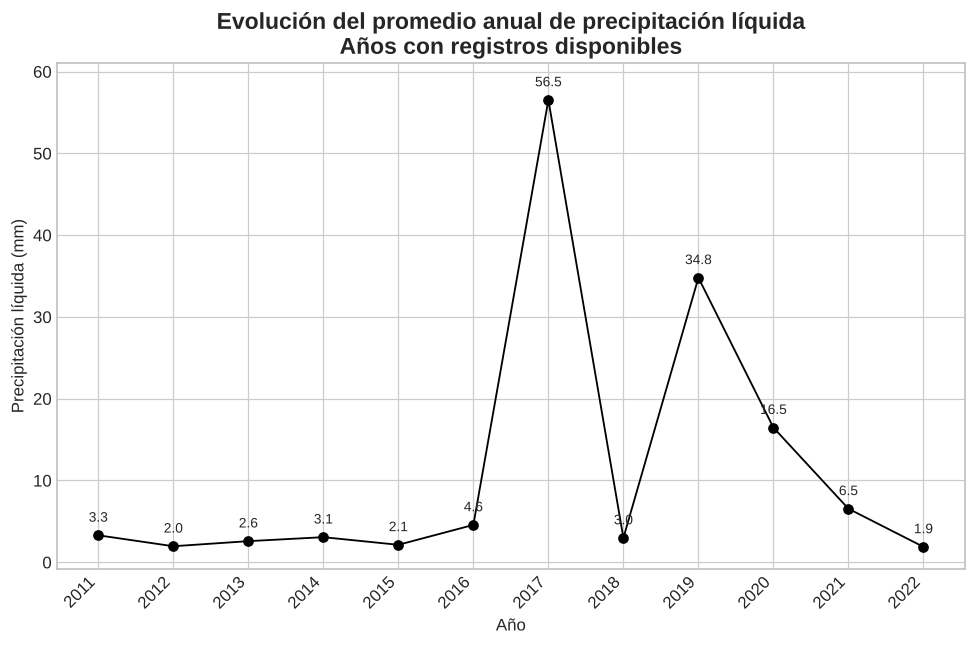

In [82]:
grafico_anual(pliquida_anual, "Promedio_PLiquida", "Evolución del promedio anual de precipitación líquida", "Años con registros disponibles", "Precipitación líquida (mm)")

```{admonition} Interpretación
:class: tip
La precipitación promedio está entre 2 y 7 mm en casi todos los años, pero 2017 (56,5 mm) y 2019 (34,8 mm) se disparan por unos pocos valores extremos. Probablemente son acumulados reportados como promedios. Para esta variable, la mediana es más representativa que la media.
```

#### Radiación global (RGlobal)

In [83]:
rglobal = df[df["Variable"] == "RGlobal"].copy()
print("Registros de RGlobal:", len(rglobal))
estadistica_rglobal = estadisticos(rglobal["Promedio"])
tabla(estadistica_rglobal, ["Estadístico", "Valor"])

Registros de RGlobal: 600


Estadístico,Valor
Mínimo,48.300000
Primer cuartil,156.880000
Mediana,178.450000
Media,185.640000
Tercer cuartil,206.400000
Máximo,431.300000


In [84]:
rglobal_anual = promedio_anual(rglobal, "Promedio_RGlobal")
tabla(rglobal_anual, ["Año", "Promedio RGlobal", "Número de registros"])

Año,Promedio RGlobal,Número de registros
2011,165.150000,19
2012,177.640000,41
2013,178.480000,43
2014,177.210000,42
2015,195.780000,38
2016,194.610000,34
2017,192.430000,71
2018,185.830000,61
2019,190.720000,43
2020,199.210000,53


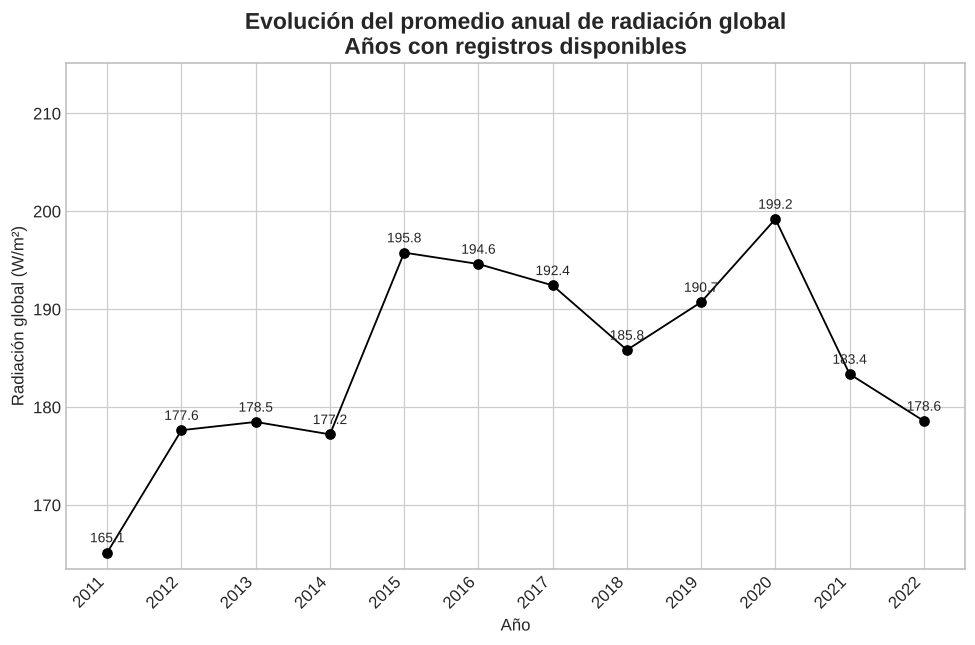

In [85]:
grafico_anual(rglobal_anual, "Promedio_RGlobal", "Evolución del promedio anual de radiación global", "Años con registros disponibles", "Radiación global (W/m²)")

```{admonition} Interpretación
:class: tip
La radiación global es estable, entre 165 y 199 W/m², con un leve aumento hasta 2020. Es coherente con la ubicación ecuatorial del país, donde la radiación varía poco a lo largo del año.
```

#### Radiación ultravioleta B (RUVb)

In [86]:
ruvb = df[df["Variable"] == "RUVb"].copy()
print("Registros de RUVb:", len(ruvb))
estadistica_ruvb = estadisticos(ruvb["Promedio"])
tabla(estadistica_ruvb, ["Estadístico", "Valor"])

Registros de RUVb: 66


Estadístico,Valor
Mínimo,0.600000
Primer cuartil,1.900000
Mediana,46.100000
Media,112.400000
Tercer cuartil,205.850000
Máximo,303.800000


In [87]:
ruvb_anual = promedio_anual(ruvb, "Promedio_RUVb")
tabla(ruvb_anual, ["Año", "Promedio RUVb", "Número de registros"])

Año,Promedio RUVb,Número de registros
2011,0.600000,2
2012,0.600000,2
2013,0.600000,2
2014,0.600000,2
2017,1.700000,4
2018,1.750000,4
2019,153.120000,12
2020,135.390000,14
2021,132.160000,14
2022,181.630000,10


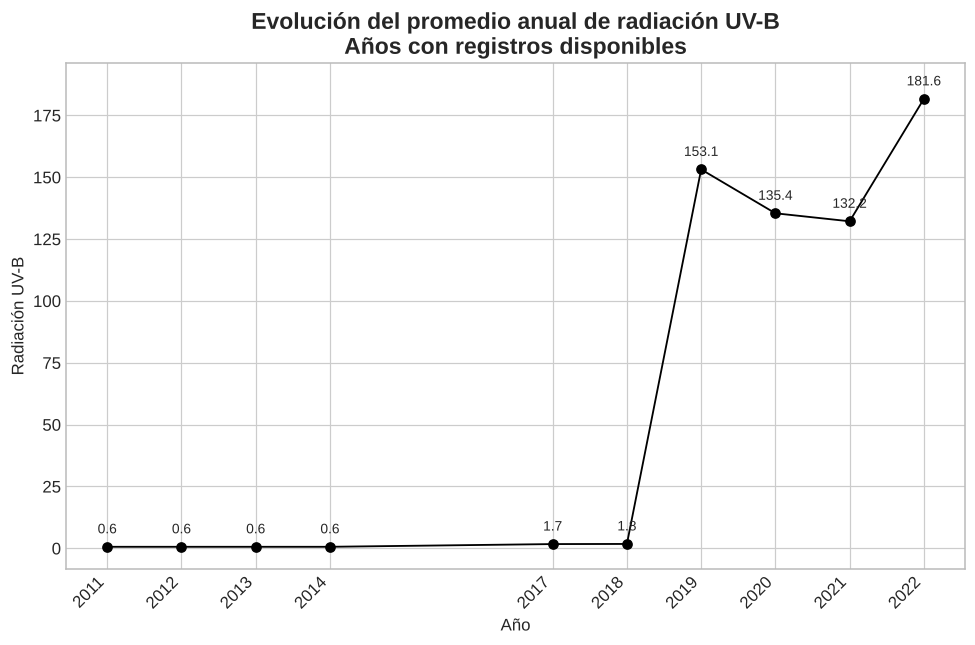

In [88]:
grafico_anual(ruvb_anual, "Promedio_RUVb", "Evolución del promedio anual de radiación UV-B", "Años con registros disponibles", "Radiación UV-B")

```{admonition} Interpretación
:class: tip
La radiación UV-B pasa de 0,6 (2011–2014) a valores entre 130 y 180 desde 2019. Un cambio así no es atmosférico; la celda siguiente muestra la causa.
```

In [89]:
ruvb.groupby("Año")["Autoridad Ambiental"].unique()

Año
2011                                    [SDA]
2012                                    [SDA]
2013                                    [SDA]
2014                                    [SDA]
2017                                   [CDMB]
2018                                   [CDMB]
2019    [CDMB, CORPOBOYACA, EPA BARRANQUILLA]
2020                 [CDMB, CORPOBOYACA, CRC]
2021                 [CDMB, CORPOBOYACA, CRC]
2022                       [CORPOBOYACA, CRC]
Name: Autoridad Ambiental, dtype: object

```{admonition} Precaución
:class: warning
Hasta 2014 la RUVb solo la reportaba la SDA (Bogotá); desde 2017 la reportan otras autoridades (CDMB, Corpoboyacá, CRC) con otra escala. La serie **no es comparable** entre los dos periodos, y cualquier correlación con RUVb será un artefacto de este cambio.
```

### 1.8 Análisis de correlaciones

*Objetivo específico 1 · asociaciones entre variables.*

#### Preparación de los datos

In [90]:
datos_correlacion = df.groupby(["Año", "Variable"], as_index=False)["Promedio"].mean().pivot(index="Año", columns="Variable", values="Promedio").reset_index().rename_axis(None, axis=1)
datos_correlacion.head()

,Año,CO,DViento,HAire,HAire10,HAire2,NO,NO2,O3,P,...,PM10,PM2.5,PST,RGlobal,RUVb,SO2,TAire,TAire10,TAire2,VViento
0,2011,1159.331250,183.766667,71.90,74.066667,72.732000,33.830769,36.280000,23.937500,634.882609,...,42.664336,21.463158,72.997500,165.147368,0.6,15.139535,20.900000,24.300000,18.330233,1.413462
1,2012,1154.315625,173.567442,70.70,68.366667,69.990741,29.894444,31.770833,27.548276,636.119355,...,44.601852,23.884848,76.111429,177.641463,0.6,11.261538,21.966667,23.866667,20.075758,1.555738
2,2013,1186.396667,139.741538,72.55,69.218519,67.887500,29.331579,30.518605,27.855556,631.593333,...,42.072671,22.162500,70.654286,178.483721,0.6,6.838462,22.075000,21.688462,20.833333,1.689888
3,2014,1219.070000,136.083077,68.34,68.829167,64.920588,32.156250,24.846939,29.013793,639.325000,...,43.639634,21.481818,75.490909,177.214286,0.6,5.915152,NaN,21.539286,21.147727,1.600000
4,2015,1019.250000,144.307937,NaN,66.184615,59.509677,27.485000,24.356604,32.640909,651.304878,...,44.396154,22.386441,80.233333,195.776316,NaN,7.258333,NaN,21.850000,20.958974,1.447253


```{admonition} Interpretación
:class: tip
Para correlacionar variables que se miden en estaciones distintas, se calcula el promedio anual nacional de cada una. Cada variable queda reducida a **máximo 14 puntos** (uno por año), y algunas tienen menos (TAire 6, HAire 7). Con tan pocos puntos, un solo año atípico puede cambiar mucho el coeficiente.
```

#### Matriz de correlaciones

In [91]:
variables_eda = ["PM10", "PM2.5", "NO2", "SO2", "O3", "TAire", "HAire", "VViento", "P", "PLiquida", "RGlobal", "RUVb"]
matriz_correlacion = datos_correlacion[[v for v in variables_eda if v in datos_correlacion.columns]].corr(method="pearson")
matriz_correlacion.round(2)

,PM10,PM2.5,NO2,SO2,O3,TAire,HAire,VViento,P,PLiquida,RGlobal,RUVb
PM10,1.00,0.97,0.44,0.23,0.59,-0.79,0.39,0.58,-0.44,-0.31,-0.17,-0.83
PM2.5,0.97,1.00,0.49,0.31,0.59,-0.58,0.66,0.51,-0.44,-0.25,-0.15,-0.70
NO2,0.44,0.49,1.00,0.52,0.05,-0.73,0.57,0.35,-0.55,-0.53,-0.71,-0.39
SO2,0.23,0.31,0.52,1.00,-0.27,-0.48,0.25,-0.34,0.08,0.08,-0.08,-0.26
O3,0.59,0.59,0.05,-0.27,1.00,-0.12,0.35,0.51,-0.42,-0.32,0.21,-0.35
TAire,-0.79,-0.58,-0.73,-0.48,-0.12,1.00,-0.07,-0.20,0.82,0.40,0.76,0.85
HAire,0.39,0.66,0.57,0.25,0.35,-0.07,1.00,0.34,-0.50,-0.17,-0.43,0.37
VViento,0.58,0.51,0.35,-0.34,0.51,-0.20,0.34,1.00,-0.31,-0.35,-0.42,-0.65
P,-0.44,-0.44,-0.55,0.08,-0.42,0.82,-0.50,-0.31,1.00,0.51,0.49,0.21
PLiquida,-0.31,-0.25,-0.53,0.08,-0.32,0.40,-0.17,-0.35,0.51,1.00,0.42,0.07


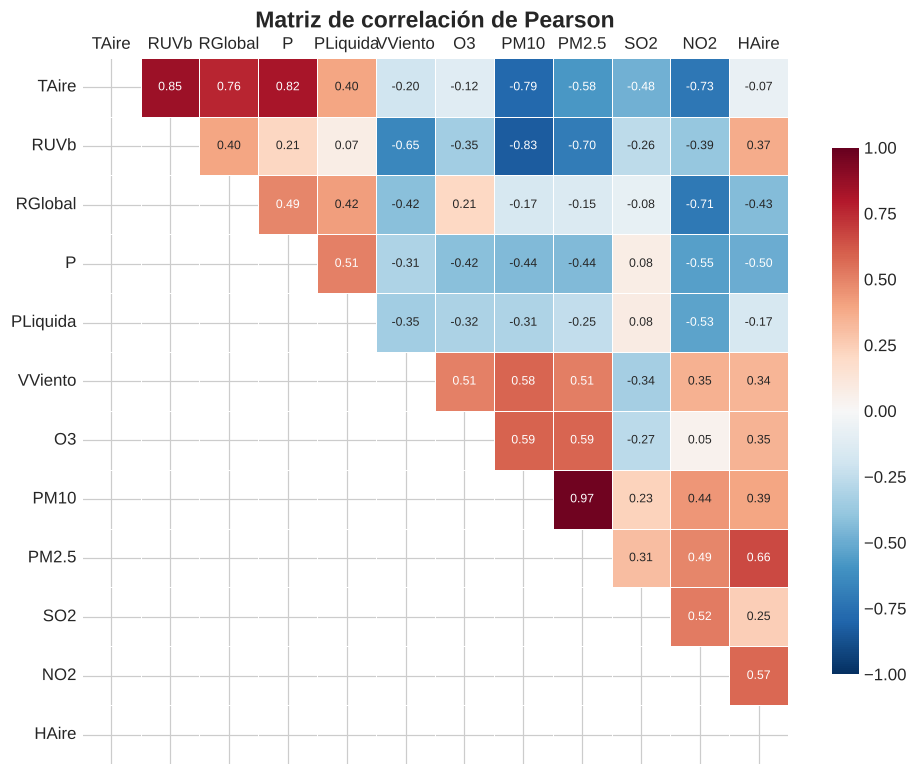

In [92]:
distancia = 1 - matriz_correlacion
orden = leaves_list(linkage(squareform(distancia.values, checks=False), method="complete"))
m = matriz_correlacion.iloc[orden, orden]
mascara = np.tril(np.ones(m.shape, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(m, mask=mascara, annot=True, fmt=".2f", annot_kws={"size": 8}, cmap="RdBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación de Pearson", fontweight="bold")
plt.xticks(rotation=45, ha="left"); ax.xaxis.tick_top()
plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
El agrupamiento jerárquico forma dos bloques. El primero reúne los contaminantes (PM10, PM2.5, O₃, SO₂, NO₂) con la velocidad del viento y la humedad, que se correlacionan positivamente entre sí. El segundo agrupa temperatura, radiación, presión y precipitación, que en general se relacionan negativamente con los contaminantes.

- **Relación robusta:** PM10–PM2.5 (r = 0,97, 14 años). El PM2.5 es una fracción del PM10 y ambos comparten fuentes (tráfico, industria, polvo resuspendido). Es la única relación fuerte sustentada por la serie completa y sin problemas de datos.
- **Plausibles pero frágiles:** TAire con PM10 (−0,79) y con NO₂ (−0,73). Más temperatura favorece la mezcla vertical y la dispersión, pero estos valores se basan en solo 6 años y en una variable con 24 % de representatividad.
- **Espurias:** todas las de RUVb (con PM10 −0,83, con TAire 0,85) y las de P, por el cambio de escala y el error de unidades vistos en la sección 1.7.
- **Con interés físico:** NO₂–RGlobal (−0,71, 12 años). La radiación solar descompone el NO₂ (fotólisis) y genera ozono, lo que es coherente con la relación negativa.

Una correlación alta no implica causalidad.
```

#### Tabla de correlaciones y fuerza de asociación

In [93]:
def fuerza(r):
    a = abs(r)
    if a >= 0.80: return "Muy fuerte"
    elif a >= 0.60: return "Fuerte"
    elif a >= 0.40: return "Moderada"
    elif a >= 0.20: return "Débil"
    else: return "Muy débil"
correlaciones_todas = datos_correlacion.select_dtypes("number").dropna().corr(method="pearson").rename_axis("Variable1").reset_index().melt(id_vars="Variable1", var_name="Variable2", value_name="Correlacion")
correlaciones_todas = correlaciones_todas[correlaciones_todas["Variable1"] != correlaciones_todas["Variable2"]].copy()
correlaciones_todas["Relacion"] = correlaciones_todas["Variable1"] + " vs. " + correlaciones_todas["Variable2"]
correlaciones_todas["Fuerza"] = correlaciones_todas["Correlacion"].apply(fuerza)
correlaciones_todas = correlaciones_todas[["Relacion", "Correlacion", "Fuerza"]].drop_duplicates(subset="Relacion").reset_index(drop=True)
correlaciones_todas.head(10)

,Relacion,Correlacion,Fuerza
0,CO vs. Año,-0.899201,Muy fuerte
1,DViento vs. Año,0.408605,Moderada
2,HAire vs. Año,-0.499833,Moderada
3,HAire10 vs. Año,-0.365553,Débil
4,HAire2 vs. Año,-0.851093,Muy fuerte
5,NO vs. Año,-0.798901,Fuerte
6,NO2 vs. Año,-0.935289,Muy fuerte
7,O3 vs. Año,-0.448068,Moderada
8,P vs. Año,0.960602,Muy fuerte
9,PLiquida vs. Año,0.598982,Moderada


```{admonition} Interpretación
:class: tip
Esta tabla usa `.dropna()` sobre las 20 variables a la vez, así que solo conserva los años con dato en **todas**: 2011, 2012, 2013, 2017, 2018 y 2019. Por eso sus valores difieren de la matriz anterior (por ejemplo PM10–PM2.5 da 0,93 aquí y 0,97 en la matriz). Con 6 puntos, una correlación de 0,8 puede aparecer por azar.

Las filas con `Año` miden tendencia: PM10 (−0,96), NO₂ (−0,94) y PM2.5 (−0,87) bajan con el tiempo, mientras que P (0,96) y RGlobal (0,90) suben. En el caso de P es otra vez el error de unidades.
```

In [94]:
def color_corr(x):
    if x >= 0.80: return "#81C784"
    elif x >= 0.60: return "#A5D6A7"
    elif x >= 0.40: return "#FFF59D"
    elif x >= 0.20: return "#FFE0B2"
    elif x <= -0.80: return "#E57373"
    elif x <= -0.60: return "#EF9A9A"
    elif x <= -0.40: return "#FFCC80"
    elif x <= -0.20: return "#FFE0B2"
    else: return "#E0E0E0"
estilos = pd.DataFrame("", index=correlaciones_todas.index, columns=correlaciones_todas.columns)
estilos["Correlacion"] = ["background-color: " + color_corr(v) + "; color: black" for v in correlaciones_todas["Correlacion"]]
estilos["Fuerza"] = estilos["Correlacion"]
correlaciones_todas.round(2).rename(columns={"Relacion": "Relación", "Correlacion": "Coeficiente de correlación"}).style.apply(lambda _: estilos.rename(columns={"Relacion": "Relación", "Correlacion": "Coeficiente de correlación"}), axis=None).hide(axis="index").set_table_styles([{"selector": "th, td", "props": [("border", "1px solid #999999"), ("padding", "4px 10px"), ("text-align", "left")]}])

Relación,Coeficiente de correlación,Fuerza
CO vs. Año,-0.900000,Muy fuerte
DViento vs. Año,0.410000,Moderada
HAire vs. Año,-0.500000,Moderada
HAire10 vs. Año,-0.370000,Débil
HAire2 vs. Año,-0.850000,Muy fuerte
NO vs. Año,-0.800000,Fuerte
NO2 vs. Año,-0.940000,Muy fuerte
O3 vs. Año,-0.450000,Moderada
P vs. Año,0.960000,Muy fuerte
PLiquida vs. Año,0.600000,Moderada


### 1.9 Análisis de valores atípicos

*Objetivo específico 1 · valores atípicos.*

In [95]:
outliers_pm = pd.DataFrame({"Variable": ["PM10", "PM2.5"], "Q1": [pm10["Promedio"].quantile(0.25), pm25["Promedio"].quantile(0.25)], "Q3": [pm10["Promedio"].quantile(0.75), pm25["Promedio"].quantile(0.75)]})
outliers_pm["Rango_IQR"] = outliers_pm["Q3"] - outliers_pm["Q1"]
outliers_pm["Limite_inferior"] = outliers_pm["Q1"] - 1.5 * outliers_pm["Rango_IQR"]
outliers_pm["Limite_superior"] = outliers_pm["Q3"] + 1.5 * outliers_pm["Rango_IQR"]
tabla(outliers_pm, ["Variable", "Primer cuartil", "Tercer cuartil", "Rango IQR", "Límite inferior", "Límite superior"])

Variable,Primer cuartil,Tercer cuartil,Rango IQR,Límite inferior,Límite superior
PM10,27.000000,44.800000,17.800000,0.300000,71.500000
PM2.5,12.500000,19.800000,7.300000,1.550000,30.750000


```{admonition} Interpretación
:class: tip
Para PM10 son atípicos los valores por encima de 71,5 µg/m³, y para PM2.5 los que superan 30,75 µg/m³. Los límites inferiores son prácticamente cero, así que no hay atípicos bajos.
```

#### Valores atípicos de PM10

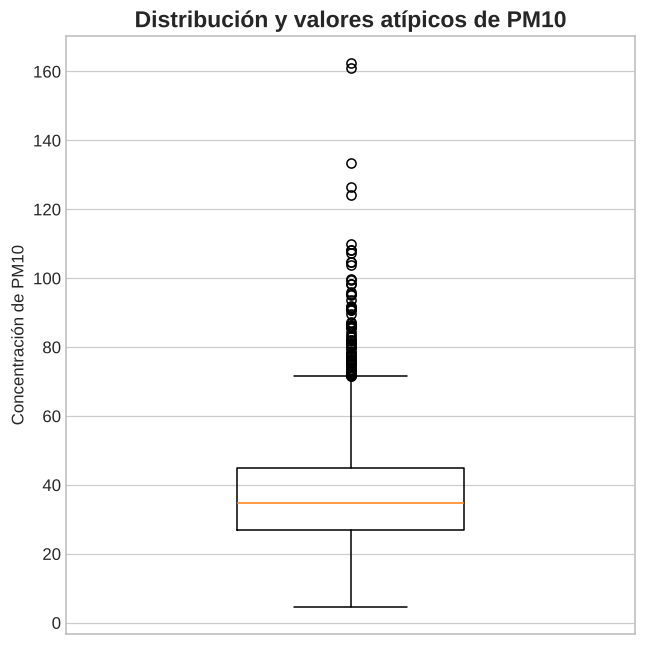

In [96]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(pm10["Promedio"].dropna(), widths=0.4)
ax.set_title("Distribución y valores atípicos de PM10", fontweight="bold"); ax.set_ylabel("Concentración de PM10"); ax.set_xticks([])
plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
PM10 tiene 91 registros atípicos (3 %), todos por encima de la caja. Los más altos están en Bogotá (estación Bolivia, 162 µg/m³ en 2012) y en zonas industriales como Yumbo y Ráquira.
```

#### Valores atípicos de PM2.5

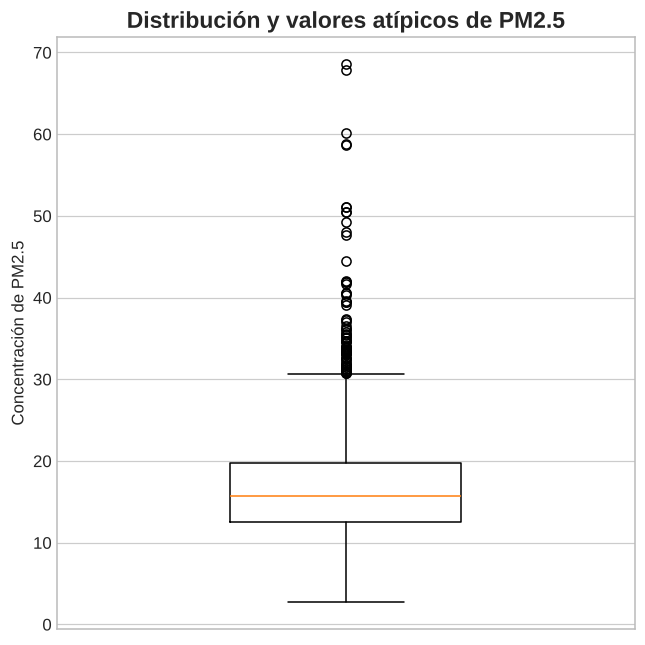

In [97]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(pm25["Promedio"].dropna(), widths=0.4)
ax.set_title("Distribución y valores atípicos de PM2.5", fontweight="bold"); ax.set_ylabel("Concentración de PM2.5"); ax.set_xticks([])
plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
PM2.5 tiene 74 atípicos (3,7 %), también solo valores altos. Que se concentren en pocas estaciones apunta a fuentes locales y no a un problema generalizado.
```

#### Valores atípicos de variables meteorológicas

In [98]:
meteorologicas = df[df["Variable"].isin(["TAire", "HAire", "VViento", "P", "PLiquida", "RGlobal", "RUVb"])]
outliers_meteorologicas = meteorologicas.groupby("Variable", as_index=False).agg(Q1=("Promedio", lambda s: s.quantile(0.25)), Q3=("Promedio", lambda s: s.quantile(0.75)))
outliers_meteorologicas["IQR"] = outliers_meteorologicas["Q3"] - outliers_meteorologicas["Q1"]
outliers_meteorologicas["Limite_inferior"] = outliers_meteorologicas["Q1"] - 1.5 * outliers_meteorologicas["IQR"]
outliers_meteorologicas["Limite_superior"] = outliers_meteorologicas["Q3"] + 1.5 * outliers_meteorologicas["IQR"]
tabla(outliers_meteorologicas, ["Variable", "Primer cuartil", "Tercer cuartil", "Rango IQR", "Límite inferior", "Límite superior"])

Variable,Primer cuartil,Tercer cuartil,Rango IQR,Límite inferior,Límite superior
HAire,62.050000,76.350000,14.300000,40.600000,97.800000
P,629.900000,755.500000,125.600000,441.500000,943.900000
PLiquida,0.200000,3.400000,3.200000,-4.600000,8.200000
RGlobal,156.880000,206.400000,49.530000,82.590000,280.690000
RUVb,1.900000,205.850000,203.950000,-304.030000,511.780000
TAire,20.600000,25.000000,4.400000,14.000000,31.600000
VViento,0.900000,1.700000,0.800000,-0.300000,2.900000


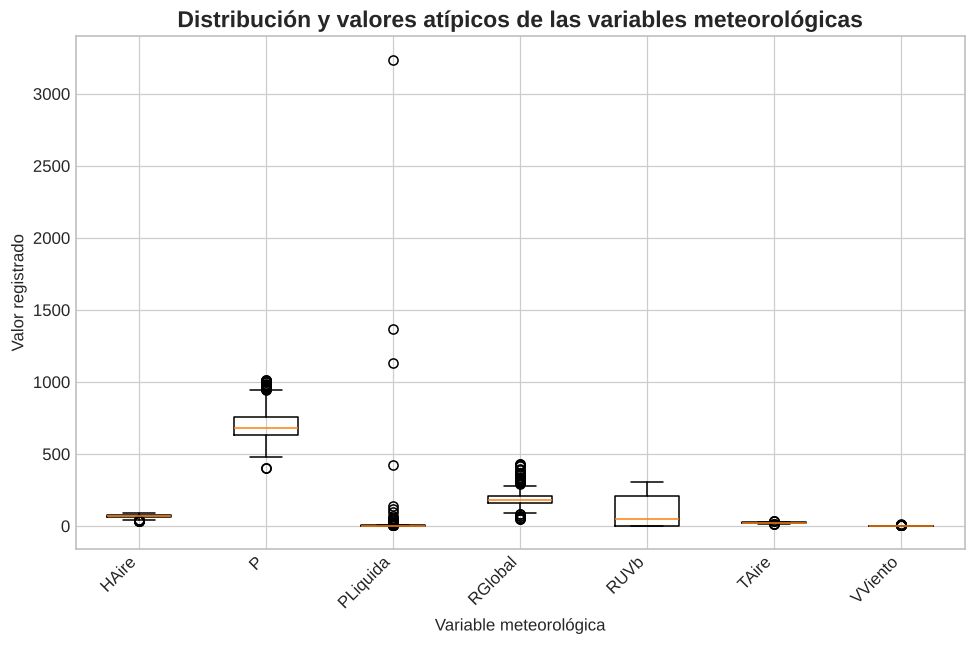

In [99]:
orden_met = sorted(meteorologicas["Variable"].unique())
fig, ax = plt.subplots()
ax.boxplot([meteorologicas.loc[meteorologicas["Variable"] == v, "Promedio"].dropna() for v in orden_met])
ax.set_xticks(range(1, len(orden_met) + 1))
ax.set_xticklabels(orden_met)
ax.set_title("Distribución y valores atípicos de las variables meteorológicas", fontweight="bold"); ax.set_xlabel("Variable meteorológica"); ax.set_ylabel("Valor registrado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
La presión tiene atípicos altos, que son los registros en hPa. La precipitación tiene valores extremos muy lejanos de la caja (acumulados). El viento tiene pocos atípicos.

**Los atípicos no se eliminan:** pueden ser episodios reales de contaminación. Las excepciones son los errores demostrables (presión en hPa, representatividad mayor a 100 %), que deben corregirse en la fuente.
```

### 1.10 Resumen estadístico general

In [100]:
variables_resumen = df[df["Variable"].isin(["PM10", "PM2.5", "SO2", "NO2", "O3", "TAire", "HAire", "VViento", "P", "PLiquida", "RGlobal", "RUVb"])].groupby("Variable", as_index=False).agg(N=("Promedio", "count"), Mínimo=("Promedio", "min"), Q1=("Promedio", lambda s: s.quantile(0.25)), Mediana=("Promedio", "median"), Media=("Promedio", "mean"), Q3=("Promedio", lambda s: s.quantile(0.75)), Máximo=("Promedio", "max"))
tabla(variables_resumen, ["Variable", "N", "Mínimo", "Q1", "Mediana", "Media", "Q3", "Máximo"])

Variable,N,Mínimo,Q1,Mediana,Media,Q3,Máximo
HAire,75,33.100000,62.050000,71.800000,66.090000,76.350000,92.000000
NO2,644,0.500000,16.500000,26.000000,26.460000,35.600000,65.600000
O3,827,2.000000,19.800000,25.700000,26.150000,31.800000,65.800000
P,673,399.100000,629.900000,677.600000,701.680000,755.500000,1010.400000
PLiquida,927,0.100000,0.200000,1.400000,9.770000,3.400000,3236.700000
PM10,2984,4.600000,27.000000,34.600000,37.130000,44.800000,162.300000
PM2.5,1984,2.700000,12.500000,15.700000,16.840000,19.800000,68.600000
RGlobal,600,48.300000,156.880000,178.450000,185.640000,206.400000,431.300000
RUVb,66,0.600000,1.900000,46.100000,112.400000,205.850000,303.800000
SO2,1066,0.100000,3.400000,6.000000,9.430000,11.000000,91.710000


```{admonition} Interpretación
:class: tip
Esta tabla resume las variables principales en un solo lugar y cierra el análisis descriptivo.
```

### 1.11 Variable objetivo: excedencia diaria de PM2.5

*Objetivo específico 2: caracterizar la variable que predecirá el modelo.*

El modelo del proyecto responderá: **¿una estación registrará en el año al menos un día con PM2.5 por encima del límite diario de la Resolución 2254 de 2017?** Antes de definirla hay que verificar qué mide exactamente la columna `Excedencias limite actual` en cada tiempo de exposición.

In [101]:
pm25["Excede"] = pm25["Excedencias limite actual"] > 0
verificacion = pm25.groupby("Tiempo de exposición (horas)").agg(
    Registros=("Excede", "size"),
    Porcentaje_que_excede=("Excede", lambda s: s.mean() * 100),
    Maximo_sin_excedencia=("Máximo", lambda s: s[~pm25.loc[s.index, "Excede"]].max()),
).reset_index()
tabla(verificacion, ["Exposición (h)", "Registros", "% que excede", "Máximo sin excedencia (µg/m³)"], decimales=1)

Exposición (h),Registros,% que excede,Máximo sin excedencia (µg/m³)
1,840,77.700000,3608.500000
24,1144,47.900000,50.200000


```{admonition} Interpretación
:class: tip
En los registros de **24 horas** ninguna estación sin excedencias supera 50,2 µg/m³, lo que coincide con el límite diario de la norma. En los de **1 hora**, en cambio, hay estaciones con máximos de 3.608 µg/m³ que figuran sin excedencias: la norma no define un límite horario para PM2.5 y esa columna no es confiable en esos registros.

**Decisión:** la variable objetivo se construye solo con los registros de 24 horas.
```

In [102]:
pm25_24h = pm25[pm25["Tiempo de exposición (horas)"] == 24].copy()
pm25_24h["Excede"] = pm25_24h["Excede"].astype(int)
print("Registros:", len(pm25_24h), "| Estaciones:", pm25_24h["Estación"].nunique())
balance = pm25_24h["Excede"].value_counts().rename_axis("Excede").reset_index(name="Registros")
balance["Porcentaje"] = balance["Registros"] / balance["Registros"].sum() * 100
tabla(balance, ["Excede (1 = sí)", "Registros", "Porcentaje"], decimales=1)

Registros: 1144 | Estaciones: 383


Excede (1 = sí),Registros,Porcentaje
0,596,52.100000
1,548,47.900000


```{admonition} Interpretación
:class: tip
La variable objetivo tiene **1.144 registros de 383 estaciones**, y el 47,9 % excede el límite. Las clases están **balanceadas**, así que el modelo no necesitará técnicas de sobremuestreo y la exactitud será una métrica razonable (junto con el AUC y el recall).
```

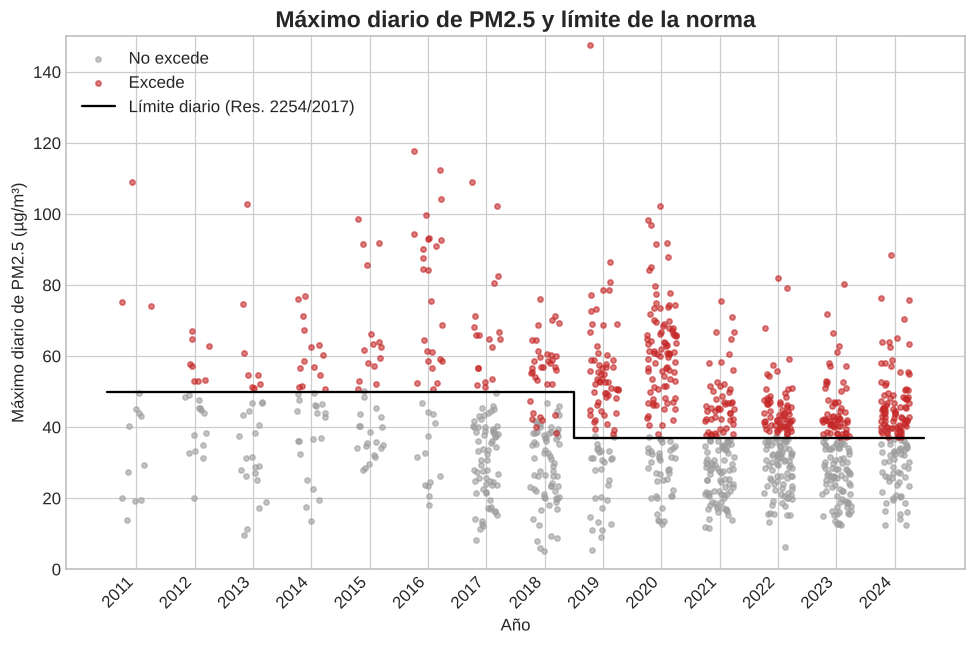

In [103]:
fig, ax = plt.subplots()
for valor, color, etiqueta in [(0, "#9e9e9e", "No excede"), (1, "#c62828", "Excede")]:
    d = pm25_24h[pm25_24h["Excede"] == valor]
    ax.scatter(d["Año"] + np.random.uniform(-0.25, 0.25, len(d)), d["Máximo"], s=12, alpha=0.6, color=color, label=etiqueta)
ax.step([2010.5, 2018.5, 2024.5], [50, 37, 37], where="post", color="black", linewidth=1.5, label="Límite diario (Res. 2254/2017)")
ax.set_ylim(0, 150); ax.set_xticks(range(2011, 2025))
ax.set_title("Máximo diario de PM2.5 y límite de la norma", fontweight="bold")
ax.set_xlabel("Año"); ax.set_ylabel("Máximo diario de PM2.5 (µg/m³)")
plt.xticks(rotation=45, ha="right"); ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
El gráfico confirma la definición: los registros que exceden (rojo) están por encima de la línea del límite y los que no exceden (gris) por debajo. El límite bajó de **50 a 37 µg/m³** a mediados de 2018, cuando entró en vigor el nivel más estricto de la norma. Por eso una misma concentración puede ser excedencia después de 2018 y no antes.
```

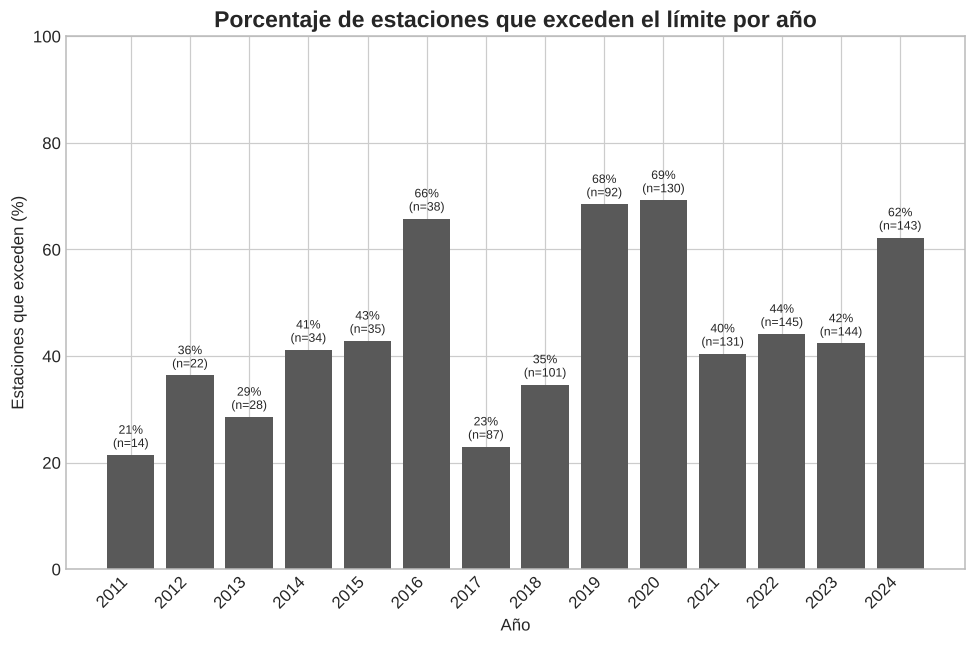

In [104]:
por_anio = pm25_24h.groupby("Año").agg(Tasa=("Excede", lambda s: s.mean() * 100), Registros=("Excede", "size")).reset_index()
fig, ax = plt.subplots()
ax.bar(por_anio["Año"].astype(str), por_anio["Tasa"], color="#595959")
for x, t, n in zip(por_anio["Año"].astype(str), por_anio["Tasa"], por_anio["Registros"]):
    ax.text(x, t + 1.5, f"{t:.0f}%\n(n={n})", ha="center", fontsize=8)
ax.set_ylim(0, 100); ax.set_title("Porcentaje de estaciones que exceden el límite por año", fontweight="bold")
ax.set_xlabel("Año"); ax.set_ylabel("Estaciones que exceden (%)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
La tasa de excedencia no tiene una tendencia clara: oscila entre 21 % (2011) y 69 % (2020). Los picos de 2016, 2019–2020 y 2024 sugieren años con episodios de contaminación más frecuentes, que podrían relacionarse con condiciones meteorológicas o incendios; el dataset no permite confirmarlo.

Dos efectos complican la lectura: entre 2011 y 2016 hay pocas estaciones (14 a 38), y en 2018 el límite se volvió más estricto. A pesar de que el promedio de PM2.5 bajó (sección 1.6), **los días con excedencias siguen siendo frecuentes**: mejorar el promedio no elimina los episodios críticos.
```

In [105]:
por_tipo = pm25_24h.groupby("Tipo de Estación").agg(Tasa=("Excede", lambda s: s.mean() * 100), n=("Excede", "size")).reset_index()
tabla(por_tipo, ["Tipo de estación", "% que excede", "Registros"], decimales=1)

Tipo de estación,% que excede,Registros
Fija,52.400000,987
Indicativa,19.700000,157


```{admonition} Interpretación
:class: tip
Las estaciones **fijas** exceden con mucha más frecuencia (52 %) que las **indicativas** (20 %). Las fijas miden todo el año y suelen estar en zonas urbanas críticas; las indicativas son campañas cortas, con menos días para registrar una excedencia.
```

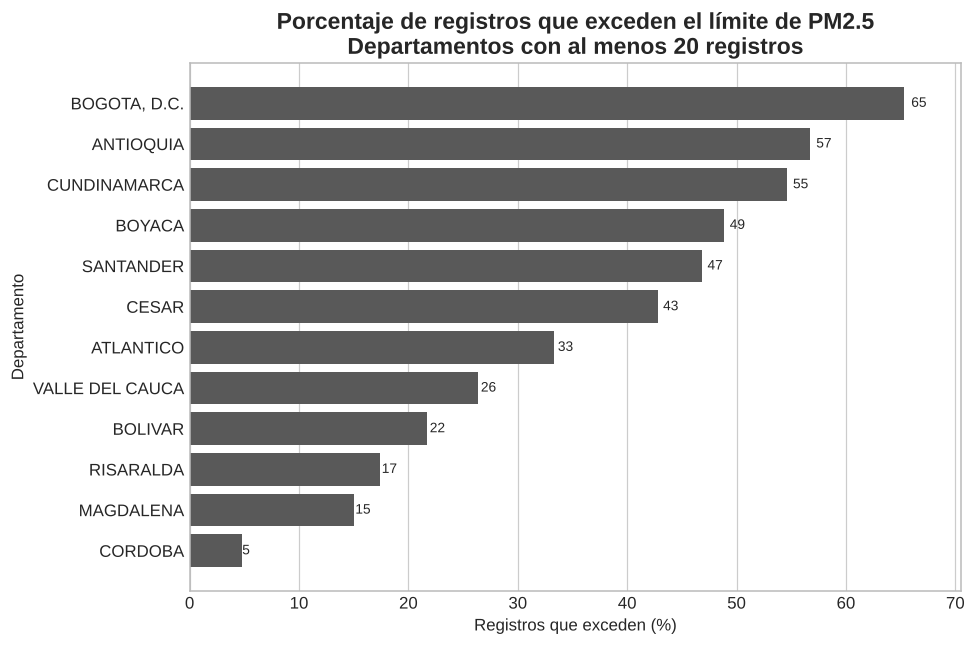

In [106]:
por_depto = pm25_24h.groupby("Departamento_norm").agg(Tasa=("Excede", lambda s: s.mean() * 100), n=("Excede", "size")).reset_index()
por_depto = por_depto[por_depto["n"] >= 20]
barras_h(por_depto, "Departamento_norm", "Tasa", "Porcentaje de registros que exceden el límite de PM2.5",
         "Registros que exceden (%)", "Departamento", subtitulo="Departamentos con al menos 20 registros", alto=6, dec=0)

```{admonition} Interpretación
:class: tip
Hay un contraste geográfico claro. **Bogotá (65 %), Antioquia (57 %) y Cundinamarca (55 %)** exceden con frecuencia, mientras que **Córdoba (5 %), Magdalena (15 %) y Bolívar (22 %)** casi no lo hacen.

Una explicación física plausible: las ciudades andinas están en valles o altiplanos donde las inversiones térmicas y el poco viento atrapan los contaminantes, mientras que en la costa Caribe los vientos alisios favorecen la dispersión. La ubicación será uno de los predictores más importantes del modelo.
```

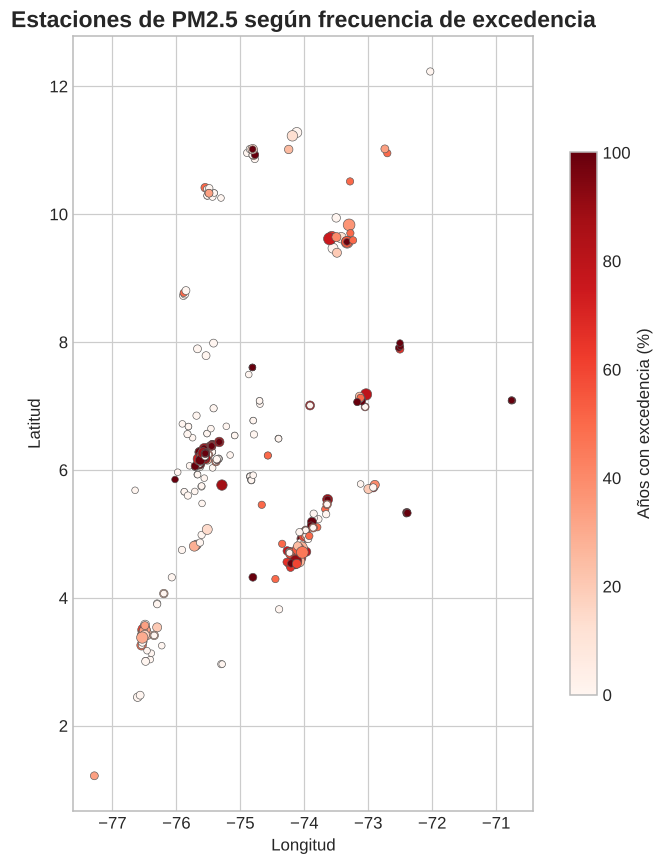

In [107]:
estaciones = pm25_24h.groupby("Estación").agg(Latitud=("Latitud", "mean"), Longitud=("Longitud", "mean"),
                                            Tasa=("Excede", "mean"), n=("Excede", "size")).reset_index()
fig, ax = plt.subplots(figsize=(7, 8))
sc = ax.scatter(estaciones["Longitud"], estaciones["Latitud"], c=estaciones["Tasa"] * 100, cmap="Reds",
                s=15 + estaciones["n"] * 4, edgecolor="#555555", linewidth=0.4, vmin=0, vmax=100)
plt.colorbar(sc, ax=ax, shrink=0.7, label="Años con excedencia (%)")
ax.set_title("Estaciones de PM2.5 según frecuencia de excedencia", fontweight="bold")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud"); ax.set_aspect("equal"); plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
El mapa muestra el mismo patrón: los puntos rojos intensos se concentran en el centro andino (Bogotá, Valle de Aburrá) y los claros en el norte (Caribe) y el suroccidente. El tamaño del punto indica cuántos años reportó la estación.
```

In [108]:
pm25_24h["Cuartil_datos"] = pd.qcut(pm25_24h["No. de datos"], 4, labels=["Q1 (menos días)", "Q2", "Q3", "Q4 (más días)"])
esfuerzo = pm25_24h.groupby("Cuartil_datos", observed=True).agg(
    Dias_medidos=("No. de datos", "median"), Tasa=("Excede", lambda s: s.mean() * 100), n=("Excede", "size")).reset_index()
tabla(esfuerzo, ["Cuartil de días medidos", "Mediana de días medidos", "% que excede", "Registros"], decimales=1)

Cuartil de días medidos,Mediana de días medidos,% que excede,Registros
Q1 (menos días),42.000000,21.100000,289
Q2,121.000000,38.200000,283
Q3,304.000000,53.500000,286
Q4 (más días),355.000000,79.000000,286


```{admonition} Interpretación
:class: tip
Este es el hallazgo más importante para el modelo. Las estaciones que midieron pocos días (Q1, mediana de 42 días) exceden en el 21 % de los casos, y las que midieron casi todo el año (Q4) en el 79 %. **Mientras más días se mide, más probable es captar al menos un día malo.**
```

```{admonition} Precaución
:class: warning
La variable objetivo depende del **esfuerzo de medición** y no solo de la calidad del aire. El modelo debe incluir `No. de datos` (o la representatividad) como predictor de control. Si no, confundirá «estación que mide mucho» con «estación contaminada».
```

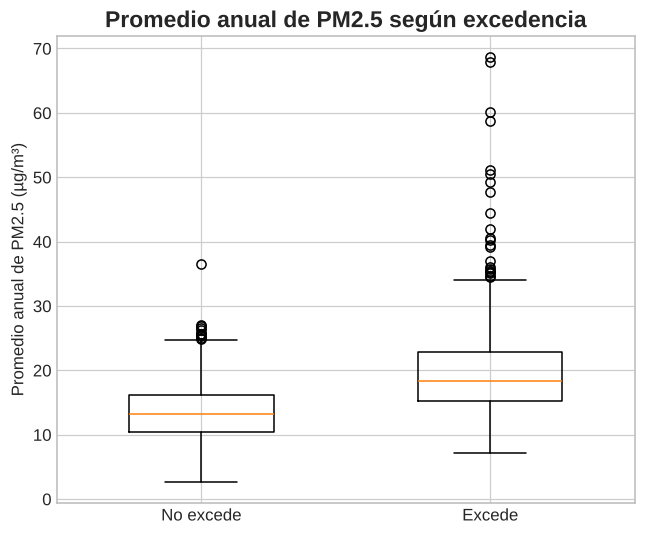

In [109]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([pm25_24h.loc[pm25_24h["Excede"] == 0, "Promedio"], pm25_24h.loc[pm25_24h["Excede"] == 1, "Promedio"]],
           widths=0.5)
ax.set_xticks([1, 2], ["No excede", "Excede"])
ax.set_title("Promedio anual de PM2.5 según excedencia", fontweight="bold")
ax.set_ylabel("Promedio anual de PM2.5 (µg/m³)"); plt.tight_layout(); plt.show()

```{admonition} Interpretación
:class: tip
Las estaciones que exceden tienen un promedio anual mayor (mediana de 18,4 frente a 13,1 µg/m³), pero las cajas se solapan: hay estaciones con promedio bajo que igual tienen días críticos. El promedio anual por sí solo no basta para anticipar las excedencias.
```

```{admonition} Precaución
:class: warning
`Promedio`, `Mediana`, `Percentil 98`, `Máximo`, `Días de excedencias` y `Porcentaje excedencias limite actual` de PM2.5 se calculan con las mismas mediciones que definen la excedencia. Usarlas como predictores sería **fuga de información** (*data leakage*): el modelo acertaría en el EDA pero sería inútil en la práctica.
```

#### Predictores candidatos para el modelo

| Variable | Uso | Razón |
|---|---|---|
| Latitud, Longitud, Departamento | ✅ Incluir | Fuerte contraste andino–Caribe |
| Tipo de estación | ✅ Incluir | Fijas 52 % vs. indicativas 20 % |
| No. de datos, Representatividad | ✅ Incluir (control) | Controlan el esfuerzo de medición |
| Año | ✅ Incluir | Captura el cambio de límite (2018) y la evolución de la red |
| Autoridad ambiental | ⚠️ Evaluar | Puede repetir la información de ubicación |
| Promedio, Mediana, P98, Máximo, Días de excedencias de PM2.5 | ❌ Excluir | Fuga de información |
| Meteorología de la misma estación | ⚠️ Evaluar | Aporta física, pero solo ~30 % de las estaciones la mide |

```{admonition} Interpretación
:class: tip
Con estos predictores, una prueba rápida con un bosque aleatorio y validación por estación (las estaciones de entrenamiento y de prueba son distintas) alcanzó un **AUC de 0,81**. El problema es viable; la etapa de modelado deberá comparar algoritmos, ajustar hiperparámetros y evaluar qué aporta la meteorología.
```